<a href="https://colab.research.google.com/github/WNderitu/data_science_capstone_project/blob/main/Malaria_parasite_detector_and_counter_notebook3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Plasmodium Vivax (malaria) parasite detector and counter notebook 3**

In this notebook, strategies for handling class imbalance are employed namely:
1. Selective oversampling of images with minority classes before training the model
2. Creating class weights that will be used in the model during training to handle class imbalance
3. Implementing various types of augmentation in the model parameters.See 1.7


## **1.0 Introduction**

Malaria, a life-threatening disease caused by Plasmodium parasites transmitted by female Anopheles mosquitoes, is most commonly found in tropical and subtropical regions. In 2023, the African Region was home to 94% and 95% of malaria cases and deaths, respectively. Sub-Saharan Africa carries a disproportionately high share of the global malaria burden. Plasmodium vivax is one of the 5 parasites that cause malaria associated with disease relapses due to dormant liver stages, contributing significantly to morbidity.

The Plasmodium vivax lifecycle alternates between humans and Anopheles mosquitoes. Infection begins when a mosquito injects sporozoites into a human, which then move to the liver to either develop or remain dormant. Merozoites released from the liver infect red blood cells, progressing through ring, trophozoite, and schizont stages, causing malaria symptoms. Some parasites develop into gametocytes, enabling further transmission via mosquitoes.

Diagnosis of Plasmodium vivax malaria relies on examining stained blood smears via microsocopy and rapid diagnostic tests, with accurate detection being key to effective treatment and relapse prevention. Advanced methods like deep learning models, such as Regional Based CNN, YOLOv8, and others would offer improved reliability and efficiency in identifying infections.

## **1.1 Problem Statement**

The detection of Plasmodium vivax malaria remains challenging, primarily due to the morphological similarities between parasite stages and other blood components observed in microscopic images. Conventional microscopy is a labor-intensive process that is susceptible to human error and demands specialized expertise, which may be limited in under-resourced settings. Consequently, there is an urgent need for automated, efficient, and dependable solutions capable of detecting and quantifying Plasmodium vivax parasites and their developmental stages within blood smears. Such advancements would enhance diagnostic accuracy, promote effective treatment, and strengthen malaria control initiatives.

## **1.2 Objectives**



1.   To develop a computer vision model for object detection and counting
2.   To detect uninfected red blood cells and leukocytes in human blood cells in a microscopic image from a blood smear using the developed YOLOv8 model
3. To count the number of uninfected red blood cells and leukocytes in human blood cells in a microscpic image from a blood smear using the developed YOLOv8 model
4. To detect the growth stage of a Plasmodium Vivax (malaria parasite) in human blood cells in a microscopic image from a blood smear using the developed YOLOv8 model
5. To count the number of detected growth stages of the plasmodium vivax parasites per microscopic image using the developed YOLOv8 model

In [5]:
from google.colab import drive

# Mount Google Drive
try:
    drive.mount('/content/drive')
    print("Google Drive mounted successfully!")
except Exception as e:
    print(f"Error mounting Google Drive: {e}")

Mounted at /content/drive
Google Drive mounted successfully!


## **1.3 Installing & Importing Required Libraries**

In [ ]:
!pip install matplotlib

In [ ]:
!pip install Pillow #installing PILLOW LIBRARY

In [ ]:
!pip install imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.5 MB/s eta 0:00:00


In [ ]:
!pip install pyyaml

In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 37.4 MB/s eta 0:00:00


In [6]:
import requests
import os
import json
import random
import shutil
from pprint import pprint # for
import PIL
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
from collections import Counter
import hashlib # find identical images
from collections import defaultdict
import numpy as np
import math # for
import yaml
from collections import Counter # Import Counter to get class counts
import shutil # for creating directories

## **1.4 Image dataset**

Dataset sourced from: https://bbbc.broadinstitute.org/BBBC041/

The dataset consists of:

image folder

training json file

test json file

The dataset consists of 1,328 microscopic images of blood smears

### **1.4.1 Downloading image dataset from website**

In [ ]:
url = "https://bbbc.broadinstitute.org/BBBC041/"
response = requests.get(url)

if response.status_code == 200:
    print("Successfully accessed the URL.") # Parse the HTML content here to find the actual data file links.
else:
    print(f"Failed to access the URL. Status code: {response.status_code}")

Successfully accessed the URL.


In [ ]:
from bs4 import BeautifulSoup
# Use BeautifulSoup & find links to data files and download them.

# Assuming 'response' from the previous cell contains the HTML content
if 'response' in locals() and response.status_code == 200:
    soup = BeautifulSoup(response.content, 'html.parser')

    # Find all links on the page
    links = soup.find_all('a')

    # Filter for links that seem to be data files (e.g., ending with .zip, .csv, etc.)
    # This is a generic approach and might need adjustment based on the actual website structure
    data_links = [link.get('href') for link in links if link.get('href') and (link.get('href').endswith('.zip') or link.get('href').endswith('.csv'))]

    # Create a directory to save the downloaded files if it doesn't exist
    download_dir = "downloaded_data"
    os.makedirs(download_dir, exist_ok=True)

    print(f"Found {len(data_links)} potential data files.")

    # Download each data file
    for data_link in data_links:
        # Construct the full URL if the link is relative
        if not data_link.startswith('http'):
            full_url = url + data_link
        else:
            full_url = data_link

        file_name = os.path.join(download_dir, os.path.basename(full_url))

        try:
            print(f"Downloading {full_url} to {file_name}...")
            with requests.get(full_url, stream=True) as r:
                r.raise_for_status()
                with open(file_name, 'wb') as f:
                    for chunk in r.iter_content(chunk_size=8192):
                        f.write(chunk)
            print("Download complete.")
        except requests.exceptions.RequestException as e:
            print(f"Error downloading {full_url}: {e}")

else:
    print("Could not proceed with downloading data. Please ensure the previous cell successfully accessed the URL.")

Found 1 potential data files.
Download complete.


Mounted at /content/drive
Google Drive mounted successfully!


In [ ]:
# Define source and destination paths
zip_file_path = 'downloaded_data/malaria.zip'
# Define the destination path in your Google Drive
# You might want to change 'malaria_dataset' to a specific folder name in your Drive
destination_path = '/content/drive/MyDrive/malaria_dataset_3/malaria.zip'

# Create the destination directory if it doesn't exist
destination_dir = os.path.dirname(destination_path)
os.makedirs(destination_dir, exist_ok=True)
print(f"Created destination directory in Google Drive: {destination_dir}")

# Copy the zip file to Google Drive
try:
    shutil.copy(zip_file_path, destination_path)
    print(f"Successfully copied {zip_file_path} to {destination_path}")
except FileNotFoundError:
    print(f"Error: The source file {zip_file_path} was not found.")
except Exception as e:
    print(f"An error occurred while copying the file: {e}")

Created destination directory in Google Drive: /content/drive/MyDrive/malaria_dataset_3
Error: The source file downloaded_data/malaria.zip was not found.


### **1.4.2 Extract contents of downloaded zip file & inspect structure of image dataset files**

In [ ]:
# extract contents of zip file
import zipfile

zip_file_path_drive = '/content/drive/MyDrive/malaria_dataset_3/malaria.zip'
extract_dir_drive = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3'

# Create the extraction directory in Google Drive if it doesn't exist
os.makedirs(extract_dir_drive, exist_ok=True)
print(f"Created extraction directory in Google Drive: {extract_dir_drive}")


try:
    with zipfile.ZipFile(zip_file_path_drive, 'r') as zip_ref:
        zip_ref.extractall(extract_dir_drive)
    print(f"Successfully extracted {zip_file_path_drive} to {extract_dir_drive}")
except FileNotFoundError:
    print(f"Error: The zip file was not found at {zip_file_path_drive}.")
except zipfile.BadZipFile:
    print(f"Error: The file {zip_file_path_drive} is not a valid zip file.")
except Exception as e:
    print(f"An error occurred during extraction: {e}")

Created extraction directory in Google Drive: /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3
Successfully extracted /content/drive/MyDrive/malaria_dataset_3/malaria.zip to /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3


In [ ]:
# List the contents of the 'malaria_extracted_3' directory
extract_dir_drive = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3'

try:
    extracted_contents = os.listdir(extract_dir_drive)
    print(f"Contents of {extract_dir_drive}:")
    pprint(extracted_contents)
except FileNotFoundError:
    print(f"Error: The directory was not found at {extract_dir_drive}")
except Exception as e:
    print(f"An error occurred: {e}")

Contents of /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3:
['malaria', '__MACOSX']


In [ ]:
# List the contents of the 'malaria' directory in malaria_extracted_3
malaria_dir = os.path.join(extract_dir_drive, 'malaria')

try:
    malaria_contents = os.listdir(malaria_dir)
    print(f"Contents of {malaria_dir}:")
    pprint(malaria_contents) # Add closing parenthesis and pprint for better display
except FileNotFoundError:
    print(f"Error: The directory was not found at {malaria_dir}")
except Exception as e:
    print(f"An error occurred: {e}")

Contents of /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria:
['images', 'labels', 'malaria_dataset_3.yaml']


In [ ]:
# rename training json to train json
old_name = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/training.json'
new_name = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/train.json'

try:
    os.rename(old_name, new_name)
    print(f"Successfully renamed {old_name} to {new_name}")
except FileNotFoundError:
    print(f"Error: The source file {old_name} was not found.")
except FileExistsError:
    print(f"Error: The destination file {new_name} already exists.")
except Exception as e:
    print(f"An error occurred: {e}")

Successfully renamed /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/training.json to /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/train.json


In [ ]:
# Check contents of train json file
train_json_path = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/train.json'

try:
    with open(train_json_path, 'r') as f:
        train_data = json.load(f)

    print(f"Contents of {train_json_path} (first entry):")
    if train_data:
        pprint(train_data[0])
    else:
        print("The train.json file is empty.")

except FileNotFoundError:
    print(f"Error: The file {train_json_path} was not found.")
except json.JSONDecodeError:
    print(f"Error: Could not decode JSON from {train_json_path}. Please check the file format.")
except Exception as e:
    print(f"An error occurred: {e}")

Contents of /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/train.json (first entry):
{'image': {'checksum': '676bb8e86fc2dbf05dd97d51a64ac0af',
           'pathname': '/images/8d02117d-6c71-4e47-b50a-6cc8d5eb1d55.png',
           'shape': {'c': 1600, 'channels': 3, 'r': 1200}},
 'objects': [{'bounding_box': {'maximum': {'c': 1540, 'r': 1158},
                               'minimum': {'c': 1440, 'r': 1057}},
              'category': 'red blood cell'},
             {'bounding_box': {'maximum': {'c': 1403, 'r': 971},
                               'minimum': {'c': 1303, 'r': 868}},
              'category': 'red blood cell'},
             {'bounding_box': {'maximum': {'c': 1008, 'r': 689},
                               'minimum': {'c': 900, 'r': 578}},
              'category': 'red blood cell'},
             {'bounding_box': {'maximum': {'c': 713, 'r': 408},
                               'minimum': {'c': 611, 'r': 304}},
              'category': 'red blood cell

The train.json file contains annotations for different objects within the images, including their categories and bounding boxes as a list. Each entry represents an image and it's annotations and is a dictionary with two main keys:

- **'image'**: This dictionary contains information about the image, such as:
  - **'checksum'**: A unique identifier for the image file
  - **'pathname'**: The path to the image file (relative to the dataset's image directory).
  - **'shape'**: The dimensions of the image (columns c and rows r), and the number of channels.

- **'objects'**: This is a list of dictionaries, where each dictionary represents a detected object within the image. Each object dictionary contains:
  - **'bounding_box'**: A dictionary specifying the coordinates of the bounding box around the object. It has:
      - **'maximum'**: A dictionary with the maximum column (c) and row (r) coordinates of the bounding box.
      - **'minimum'**: A dictionary with the minimum column (c) and row (r) coordinates of the bounding box.
  - **'category'**: A string indicating the class or type of the object detected (e.g., 'red blood cell', 'trophozoite').

In [ ]:
# Check contents of test json file
test_json_path = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/test.json'

try:
    with open(test_json_path, 'r') as f:
        test_data = json.load(f)

    print(f"Contents of {train_json_path} (first entry):")
    if test_data:
        pprint(test_data[0])
    else:
        print("The test.json file is empty.")

except FileNotFoundError:
    print(f"Error: The file {test_json_path} was not found.")
except json.JSONDecodeError:
    print(f"Error: Could not decode JSON from {test_json_path}. Please check the file format.")
except Exception as e:
    print(f"An error occurred: {e}")

Contents of /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/train.json (first entry):
{'image': {'checksum': 'eea3bfd6a929bcb06f9786667cd3fbb2',
           'pathname': '/images/41be1bd3-0d31-4881-bf1f-3ccdfa21ff12.jpg',
           'shape': {'c': 1944, 'channels': 3, 'r': 1383}},
 'objects': [{'bounding_box': {'maximum': {'c': 1883, 'r': 708},
                               'minimum': {'c': 1744, 'r': 576}},
              'category': 'red blood cell'},
             {'bounding_box': {'maximum': {'c': 1373, 'r': 977},
                               'minimum': {'c': 1249, 'r': 863}},
              'category': 'red blood cell'},
             {'bounding_box': {'maximum': {'c': 1711, 'r': 335},
                               'minimum': {'c': 1573, 'r': 210}},
              'category': 'red blood cell'},
             {'bounding_box': {'maximum': {'c': 1253, 'r': 1142},
                               'minimum': {'c': 1124, 'r': 1017}},
              'category': 'red blood c

same as for train json file

In [ ]:
# Get number of test and train images

# Assuming train_data and test_data are available from previous cell executions
if 'train_data' in locals():
    num_train_images = len(train_data)
    print(f"Number of images in the train dataset: {num_train_images}")
else:
    print("Train data not loaded. Please run the cell that loads 'train.json'.")
    num_train_images = 0

if 'test_data' in locals():
    num_test_images = len(test_data)
    print(f"Number of images in the test dataset: {num_test_images}")
else:
    print("Test data not loaded. Please run the cell that loads 'test.json'.")
    num_test_images = 0

total_images = num_train_images + num_test_images

if total_images > 0:
    train_proportion = num_train_images / total_images
    test_proportion = num_test_images / total_images
    print(f"\nProportion of train images: {train_proportion:.2f}")
    print(f"Proportion of test images: {test_proportion:.2f}")
else:
    print("\nNo images loaded to calculate proportions.")

Number of images in the train dataset: 1208
Number of images in the test dataset: 120

Proportion of train images: 0.91
Proportion of test images: 0.09


In [ ]:
# 3. Create Validation Directory
# Create a new directory for the validation images and their corresponding labels in your Google Drive.

base_dir = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria'
val_image_dir = os.path.join(base_dir, 'images', 'val')
val_labels_dir = os.path.join(base_dir, 'labels', 'val')

# Create the directories if they don't exist
os.makedirs(val_image_dir, exist_ok=True)
os.makedirs(val_labels_dir, exist_ok=True)

print(f"Created validation image directory: {val_image_dir}")
print(f"Created validation labels directory: {val_labels_dir}")

Created validation image directory: /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/images/val
Created validation labels directory: /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels/val


In [ ]:
image_folder_path = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/images'

try:
    # List all files in the image folder
    image_files_with_extensions = os.listdir(image_folder_path)

    # Define common image extensions (you can add more if needed)
    image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']

    # Filter files to include only those with common image extensions
    image_files = [f for f in image_files_with_extensions if os.path.splitext(f)[1].lower() in image_extensions]

    # Count the number of filtered files
    num_total_images = len(image_files)

    print(f"Total number of image files in the image folder (with extensions {', '.join(image_extensions)}): {num_total_images}")

except FileNotFoundError:
    print(f"Error: The image folder was not found at {image_folder_path}")
except Exception as e:
    print(f"An error occurred: {e}")

Total number of image files in the image folder (with extensions .jpg, .jpeg, .png, .bmp, .tiff): 1328


## **1.5 Data cleaning & inspection of images**

### **1.5.1 Split & move images in image folder into 2 folders: test & train images**

In [ ]:
# create the test and train folders in Google Drive
base_image_dir = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/images'
train_image_dir = os.path.join(base_image_dir, 'train')
test_image_dir = os.path.join(base_image_dir, 'test')

# Create the directories if they don't exist
os.makedirs(train_image_dir, exist_ok=True)
os.makedirs(test_image_dir, exist_ok=True)

print(f"Created directory: {train_image_dir}")
print(f"Created directory: {test_image_dir}")

Created directory: /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/images/train
Created directory: /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/images/test


In [ ]:
# Load the training and testing data from Google Drive
train_json_path = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/train.json'
test_json_path = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/test.json'

base_dir = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria'
train_image_dir = os.path.join(base_dir, 'images', 'train')
test_image_dir = os.path.join(base_dir, 'images', 'test')

# Create the directories if they don't exist
os.makedirs(train_image_dir, exist_ok=True)
os.makedirs(test_image_dir, exist_ok=True)


try:
    with open(train_json_path, 'r') as f:
        train_data = json.load(f)
    with open(test_json_path, 'r') as f:
        test_data = json.load(f)

    # Move training images
    print("Moving training images...")
    for entry in train_data:
        image_pathname = entry['image']['pathname']
        # Construct the source path correctly from the base_dir and image_pathname
        source_path = os.path.join(base_dir, image_pathname.lstrip('/'))
        destination_path = os.path.join(train_image_dir, os.path.basename(image_pathname))


        try:
            shutil.move(source_path, destination_path)
        except FileNotFoundError:
            print(f"Warning: Image file not found for training data at {source_path}")
        except Exception as e:
            print(f"An error occurred while moving training image {source_path}: {e}")

    # Move testing images
    print("Moving testing images...")
    for entry in test_data:
        image_pathname = entry['image']['pathname']
        # Construct the source path correctly from the base_dir and image_pathname
        source_path = os.path.join(base_dir, image_pathname.lstrip('/'))
        destination_path = os.path.join(test_image_dir, os.path.basename(image_pathname))
        try:
            shutil.move(source_path, destination_path)
        except FileNotFoundError:
            print(f"Warning: Image file not found for testing data at {source_path}")
        except Exception as e:
            print(f"An error occurred while moving testing image {source_path}: {e}")

    print("Image separation complete.")

except FileNotFoundError as e:
    print(f"Error: JSON file not found: {e}")
except json.JSONDecodeError as e:
    print(f"Error: Could not decode JSON from file: {e}")
except Exception as e:
    print(f"An unexpected error occurred: {e}")

Moving training images...
Moving testing images...
Image separation complete.


### **1.5.2 Create a labels folder to contain the json files**

In [ ]:
# Define the paths
base_dir = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria'
labels_dir = os.path.join(base_dir, 'labels')
train_json_path = os.path.join(base_dir, 'train.json')
test_json_path = os.path.join(base_dir, 'test.json')

# Create the labels directory if it doesn't exist
os.makedirs(labels_dir, exist_ok=True)
print(f"Created directory: {labels_dir}")

# Move the train.json file
try:
    shutil.move(train_json_path, labels_dir)
    print(f"Moved {train_json_path} to {labels_dir}")
except FileNotFoundError:
    print(f"Error: {train_json_path} not found.")
except Exception as e:
    print(f"An error occurred while moving {train_json_path}: {e}")

# Move the test.json file
try:
    shutil.move(test_json_path, labels_dir)
    print(f"Moved {test_json_path} to {labels_dir}")
except FileNotFoundError:
    print(f"Error: {test_json_path} not found.")
except Exception as e:
    print(f"An error occurred while moving {test_json_path}: {e}")

Created directory: /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels
Moved /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/train.json to /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels
Moved /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/test.json to /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels


### **1.5.2 Create a validation folder containing validation images from train images**

In [ ]:
# 1. Calculate split sizes
# Determine number of images needed for train and validation sets based on the desired 70/20/10 ratio and the total number of images.

# num_total_images and num_test_images is available from a previous cell's execution

# Calculate the number of images currently in the training set
num_current_train_images = num_total_images - num_test_images
print(f"Number of images currently in the training set: {num_current_train_images}")

# Desired split percentages for the *current* training set
train_percent_new = 0.70 / (0.70 + 0.20) # Recalculate based on the current train/val portion
val_percent_new = 0.20 / (0.70 + 0.20)

# Calculate desired number of images for the new train and validation sets from the *current* training set
desired_num_train = int(num_current_train_images * train_percent_new)
desired_num_val = num_current_train_images - desired_num_train # Assign the rest to validation to avoid rounding issues

print(f"\nTotal number of images: {num_total_images}")
print(f"Number of images currently in the training set: {num_current_train_images}")
print(f"Number of test images (10%): {num_test_images}")
print(f"\nDesired number of images for the new training set (approx 70% of current train): {desired_num_train}")
print(f"Desired number of validation images (approx 20% of current train): {desired_num_val}")


# Verify that the new desired counts for train and val add up to the current train total
print(f"Sum of new train and validation counts: {desired_num_train + desired_num_val}")
# Verify that the total count across all sets (new train + val + test) matches the original total
print(f"Total count across all sets (new train + val + test): {desired_num_train + desired_num_val + num_test_images}")

# Calculate how many images need to be moved from the current training set to the validation set
num_images_to_move_to_val = desired_num_val

print(f"\nNumber of images to move from the current training set to the validation set: {num_images_to_move_to_val}")

# Store calculated sizes for the next steps
train_size = desired_num_train
val_size = desired_num_val

Number of images currently in the training set: 1208

Total number of images: 1328
Number of images currently in the training set: 1208
Number of test images (10%): 120

Desired number of images for the new training set (approx 70% of current train): 939
Desired number of validation images (approx 20% of current train): 269
Sum of new train and validation counts: 1208
Total count across all sets (new train + val + test): 1328

Number of images to move from the current training set to the validation set: 269


In [ ]:
# 2. Select Validation Images
# Randomly select the calculated number of images from the current training set to be the validation images.

# Assuming train_data is available from a previous cell's execution and contains all current training data entries.
# Assuming desired_num_val is available from the previous step's calculation.

if 'train_data' in locals() and train_data and 'desired_num_val' in locals() and desired_num_val > 0:
    # Shuffle the training data to ensure random selection
    random.shuffle(train_data)

    # Select the first 'desired_num_val' entries for the validation set
    val_data = train_data[:desired_num_val]

    # The remaining entries will form the new training set
    new_train_data = train_data[desired_num_val:]

    print(f"Selected {len(val_data)} images for the validation set.")
    print(f"Remaining {len(new_train_data)} images for the new training set.")

    # Update the train_data variable to hold the new training set
    train_data = new_train_data

else:
    print("Could not select validation images. Please ensure train_data is loaded and desired_num_val is calculated and greater than 0.")
    val_data = []
    new_train_data = train_data if 'train_data' in locals() else [] # Keep original train_data if selection failed

Selected 269 images for the validation set.
Remaining 939 images for the new training set.


In [ ]:
# 3. Create Validation Directory
# Create a new directory for the validation images and their corresponding labels in your Google Drive.

base_dir = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria'
val_image_dir = os.path.join(base_dir, 'images', 'val')
val_labels_dir = os.path.join(base_dir, 'labels', 'val')

# Create the directories if they don't exist
os.makedirs(val_image_dir, exist_ok=True)
os.makedirs(val_labels_dir, exist_ok=True)

print(f"Created validation image directory: {val_image_dir}")
print(f"Created validation labels directory: {val_labels_dir}")

Created validation image directory: /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/images/val
Created validation labels directory: /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels/val


In [ ]:
# 4. Move Validation Images and Labels
# Move the selected images and their corresponding JSON entries (annotations)
# from the training directories to the newly created validation directories.

# Assuming val_data contains the list of entries for the validation set
# Assuming train_data now contains the remaining entries for the new training set
# Assuming train_image_dir, val_image_dir, train_labels_dir, and val_labels_dir are defined with correct paths in Google Drive

if 'val_data' in locals() and val_data and 'train_data' in locals() and train_data:

    base_dir = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria'
    train_image_dir = os.path.join(base_dir, 'images', 'train')
    val_image_dir = os.path.join(base_dir, 'images', 'val')
    train_labels_dir = os.path.join(base_dir, 'labels', 'train') # Assuming a train labels directory will be used/created
    val_labels_dir = os.path.join(base_dir, 'labels', 'val')

    # Create train labels directory if it doesn't exist (to store the updated train.json)
    os.makedirs(train_labels_dir, exist_ok=True)
    print(f"Ensured train labels directory exists: {train_labels_dir}")


    print("\nMoving validation images and labels...")

    # Move images and prepare validation annotations
    val_annotations_list = []
    for entry in val_data:
        image_pathname = os.path.basename(entry['image']['pathname'])
        original_image_path = os.path.join(train_image_dir, image_pathname)
        destination_image_path = os.path.join(val_image_dir, image_pathname)

        try:
            shutil.move(original_image_path, destination_image_path)
            # Add the entry to the validation annotations list
            val_annotations_list.append(entry)
        except FileNotFoundError:
            print(f"Warning: Image file not found for validation data at {original_image_path}. Skipping move.")
        except Exception as e:
            print(f"An error occurred while moving validation image {original_image_path}: {e}")

    print("Validation images moved.")

    # The annotations for the new training set are already in the updated train_data list
    print("Validation images and labels move process complete.")

else:
    print("Could not move validation images and labels. Please ensure val_data and train_data are available.")

Ensured train labels directory exists: /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels/train

Moving validation images and labels...
Validation images moved.
Validation images and labels move process complete.


In [ ]:
# 5. Update Train and Validation JSONs
# Update the train.json and create a new val.json file to reflect the new image distribution.

# Assuming train_data contains the entries for the new training set
# Assuming val_annotations_list contains the entries for the validation set
# Assuming train_labels_dir and val_labels_dir are defined with correct paths in Google Drive

if 'train_data' in locals() and 'val_annotations_list' in locals():

    train_labels_dir = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels/train'
    val_labels_dir = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels/val'

    train_json_path_updated = os.path.join(train_labels_dir, 'train.json')
    val_json_path_new = os.path.join(val_labels_dir, 'val.json')

    # Save the updated train.json file
    try:
        with open(train_json_path_updated, 'w') as f:
            json.dump(train_data, f, indent=4)
        print(f"Updated train.json saved to: {train_json_path_updated}")
    except Exception as e:
        print(f"Error saving updated train.json: {e}")

    # Save the new val.json file
    try:
        with open(val_json_path_new, 'w') as f:
            json.dump(val_annotations_list, f, indent=4)
        print(f"New val.json saved to: {val_json_path_new}")
    except Exception as e:
        print(f"Error saving new val.json: {e}")

else:
    print("Could not update/create JSON files. Please ensure train_data and val_annotations_list are available.")

Updated train.json saved to: /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels/train/train.json
New val.json saved to: /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels/val/val.json


In [ ]:
# 6. Verify Split
# Check the number of images in each directory (train, validation, and test) to confirm the 70/20/10 split is achieved.

# Assuming train_image_dir, val_image_dir, and test_image_dir are defined with correct paths in Google Drive

train_image_dir = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/images/train'
val_image_dir = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/images/val'
test_image_dir = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/images/test'


def count_images_in_dir(directory):
    """Counts the number of files (assumed to be images) in a directory."""
    if not os.path.exists(directory):
        print(f"Warning: Directory not found at {directory}")
        return 0
    try:
        # Count only files, not directories
        return len([f for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))])
    except Exception as e:
        print(f"Error counting images in {directory}: {e}")
        return 0

num_train_files = count_images_in_dir(train_image_dir)
num_val_files = count_images_in_dir(val_image_dir)
num_test_files = count_images_in_dir(test_image_dir)

print(f"Number of images in the training set: {num_train_files}")
print(f"Number of images in the validation set: {num_val_files}")
print(f"Number of images in the test set: {num_test_files}")

total_files_counted = num_train_files + num_val_files + num_test_files
print(f"\nTotal images counted: {total_files_counted}")

# Assuming num_total_images is available from previous calculations
if 'num_total_images' in locals():
    print(f"Original total images: {num_total_images}")
    if total_files_counted == num_total_images:
        print("Total images counted across all sets matches the original total.")
    else:
        print("Warning: Total images counted across all sets does NOT match the original total.")


# Assuming desired_num_train, desired_num_val, and num_test_images are available from previous calculations
if 'desired_num_train' in locals() and 'desired_num_val' in locals() and 'num_test_images' in locals():
    print(f"\nDesired train images: {desired_num_train}")
    print(f"Desired validation images: {desired_num_val}")
    print(f"Desired test images: {num_test_images}")

    # Check if the counts are close to the desired numbers (allowing for small rounding differences)
    print("\nVerification against desired counts (allowing for rounding):")
    if abs(num_train_files - desired_num_train) <= 1: # Allow difference of up to 1 for rounding
        print(f"Train count ({num_train_files}) is close to desired ({desired_num_train}).")
    else:
        print(f"Warning: Train count ({num_train_files}) significantly differs from desired ({desired_num_train}).")

    if abs(num_val_files - desired_num_val) <= 1: # Allow difference of up to 1 for rounding
        print(f"Validation count ({num_val_files}) is close to desired ({desired_num_val}).")
    else:
        print(f"Warning: Validation count ({num_val_files}) significantly differs from desired ({desired_num_val}).")

    if num_test_files == num_test_images: # Test count should match exactly
        print(f"Test count ({num_test_files}) matches desired ({num_test_images}).")
    else:
         print(f"Warning: Test count ({num_test_files}) does NOT match desired ({num_test_images}).")

Number of images in the training set: 939
Number of images in the validation set: 269
Number of images in the test set: 120

Total images counted: 1328
Original total images: 1328
Total images counted across all sets matches the original total.

Desired train images: 939
Desired validation images: 269
Desired test images: 120

Verification against desired counts (allowing for rounding):
Train count (939) is close to desired (939).
Validation count (269) is close to desired (269).
Test count (120) matches desired (120).


In [ ]:
def list_directory_structure(startpath, indent=''):
    """Recursively lists the directory structure."""
    if not os.path.exists(startpath):
        print(f"Directory not found: {startpath}")
        return

    items = os.listdir(startpath)
    # Sort items to have a consistent output
    items.sort()

    for i, item in enumerate(items):
        # Ignore the __MACOSX directory
        if item == '__MACOSX':
            continue

        full_path = os.path.join(startpath, item)
        # Determine if it's the last item in the list for proper tree formatting
        is_last = i == len(items) - 1

        # Print the current item with tree structure
        print(indent + ('└── ' if is_last else '├── ') + item)

        # If it's a directory, recursively call the function
        if os.path.isdir(full_path):
            next_indent = indent + ('    ' if is_last else '│   ')
            list_directory_structure(full_path, next_indent)

# Define the base directory for the malaria dataset in Google Drive
base_malaria_dir = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria'

print(f"Directory structure for: {base_malaria_dir}")
list_directory_structure(base_malaria_dir)

Directory structure for: /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria
├── images
│   ├── test
│   │   ├── 010961af-b38c-49de-aca0-e3732d73d414.jpg
│   │   ├── 0346611b-ea43-45bd-9f16-c6e8086273d2.jpg
│   │   ├── 03be08c8-2cf3-4de6-8ac6-5f7817a6a643.jpg
│   │   ├── 06bbcd42-3ba8-4476-8804-8455f56dd928.jpg
│   │   ├── 0864c569-2ad7-48ed-b12a-e40aa5b93756.jpg
│   │   ├── 087602a2-288b-4a4d-b01a-524f0d799d89.jpg
│   │   ├── 0897f682-5301-49fc-a8d5-9df7762040bb.jpg
│   │   ├── 0a3b53c7-e7ab-4135-80aa-fd2079d727d6.jpg
│   │   ├── 0e0bc36f-6fb2-4763-b0a1-b4c67b2d2d2a.jpg
│   │   ├── 15625643-d964-4b14-9839-c126384ae35b.jpg
│   │   ├── 15a5849d-8bc7-4e01-938b-c1f55067787d.jpg
│   │   ├── 1b814efc-7bf9-40ae-8e13-49dc2c04732f.jpg
│   │   ├── 1e647046-333b-4102-a0c6-4c29405c37b3.jpg
│   │   ├── 21116b9d-e6be-483f-8394-e74622b2e182.jpg
│   │   ├── 224c80b8-6c55-48cf-b719-96a47d223dc3.jpg
│   │   ├── 23e581e7-0fb7-42ff-ba55-a86beefc0619.jpg
│   │   ├── 25865b39-56fb-409a-880

In [ ]:
# Remove the extra train.json file directly under the labels directory
extra_train_json_path = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels/train.json'

if os.path.exists(extra_train_json_path):
    try:
        os.remove(extra_train_json_path)
        print(f"Removed extra file: {extra_train_json_path}")
    except Exception as e:
        print(f"Error removing file {extra_train_json_path}: {e}")
else:
    print(f"Extra file not found: {extra_train_json_path}")

Removed extra file: /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels/train.json


In [ ]:
# Define the path to the labels directory
labels_dir = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels'

# Define the path for the new test labels directory
test_labels_dir = os.path.join(labels_dir, 'test')

# Create the directory if it doesn't exist
os.makedirs(test_labels_dir, exist_ok=True)

print(f"Created test labels directory: {test_labels_dir}")

Created test labels directory: /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels/test


In [ ]:
# Define the source path for the test.json file
source_test_json_path = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels/test.json'

# Define the destination path for the test.json file
destination_test_json_path = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels/test/test.json'

# Move the test.json file
try:
    shutil.move(source_test_json_path, destination_test_json_path)
    print(f"Moved {source_test_json_path} to {destination_test_json_path}")
except FileNotFoundError:
    print(f"Error: The source file {source_test_json_path} was not found.")
except FileExistsError:
    print(f"Error: The destination file {destination_test_json_path} already exists.")
except Exception as e:
    print(f"An error occurred while moving the file: {e}")

Moved /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels/test.json to /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels/test/test.json


In [ ]:
def list_directory_structure(startpath, indent=''):
    """Recursively lists the directory structure."""
    if not os.path.exists(startpath):
        print(f"Directory not found: {startpath}")
        return

    items = os.listdir(startpath)
    # Sort items to have a consistent output
    items.sort()

    for i, item in enumerate(items):
        # Ignore the __MACOSX directory
        if item == '__MACOSX':
            continue

        full_path = os.path.join(startpath, item)
        # Determine if it's the last item in the list for proper tree formatting
        is_last = i == len(items) - 1

        # Print the current item with tree structure
        print(indent + ('└── ' if is_last else '├── ') + item)

        # If it's a directory, recursively call the function
        if os.path.isdir(full_path):
            next_indent = indent + ('    ' if is_last else '│   ')
            list_directory_structure(full_path, next_indent)

# Define the base directory for the malaria dataset in Google Drive
base_malaria_dir = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria'

print(f"Directory structure for: {base_malaria_dir}")
list_directory_structure(base_malaria_dir)

Directory structure for: /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria
├── images
│   ├── test
│   │   ├── 010961af-b38c-49de-aca0-e3732d73d414.jpg
│   │   ├── 0346611b-ea43-45bd-9f16-c6e8086273d2.jpg
│   │   ├── 03be08c8-2cf3-4de6-8ac6-5f7817a6a643.jpg
│   │   ├── 06bbcd42-3ba8-4476-8804-8455f56dd928.jpg
│   │   ├── 0864c569-2ad7-48ed-b12a-e40aa5b93756.jpg
│   │   ├── 087602a2-288b-4a4d-b01a-524f0d799d89.jpg
│   │   ├── 0897f682-5301-49fc-a8d5-9df7762040bb.jpg
│   │   ├── 0a3b53c7-e7ab-4135-80aa-fd2079d727d6.jpg
│   │   ├── 0e0bc36f-6fb2-4763-b0a1-b4c67b2d2d2a.jpg
│   │   ├── 15625643-d964-4b14-9839-c126384ae35b.jpg
│   │   ├── 15a5849d-8bc7-4e01-938b-c1f55067787d.jpg
│   │   ├── 1b814efc-7bf9-40ae-8e13-49dc2c04732f.jpg
│   │   ├── 1e647046-333b-4102-a0c6-4c29405c37b3.jpg
│   │   ├── 21116b9d-e6be-483f-8394-e74622b2e182.jpg
│   │   ├── 224c80b8-6c55-48cf-b719-96a47d223dc3.jpg
│   │   ├── 23e581e7-0fb7-42ff-ba55-a86beefc0619.jpg
│   │   ├── 25865b39-56fb-409a-880

### **1.5.3 View train images**

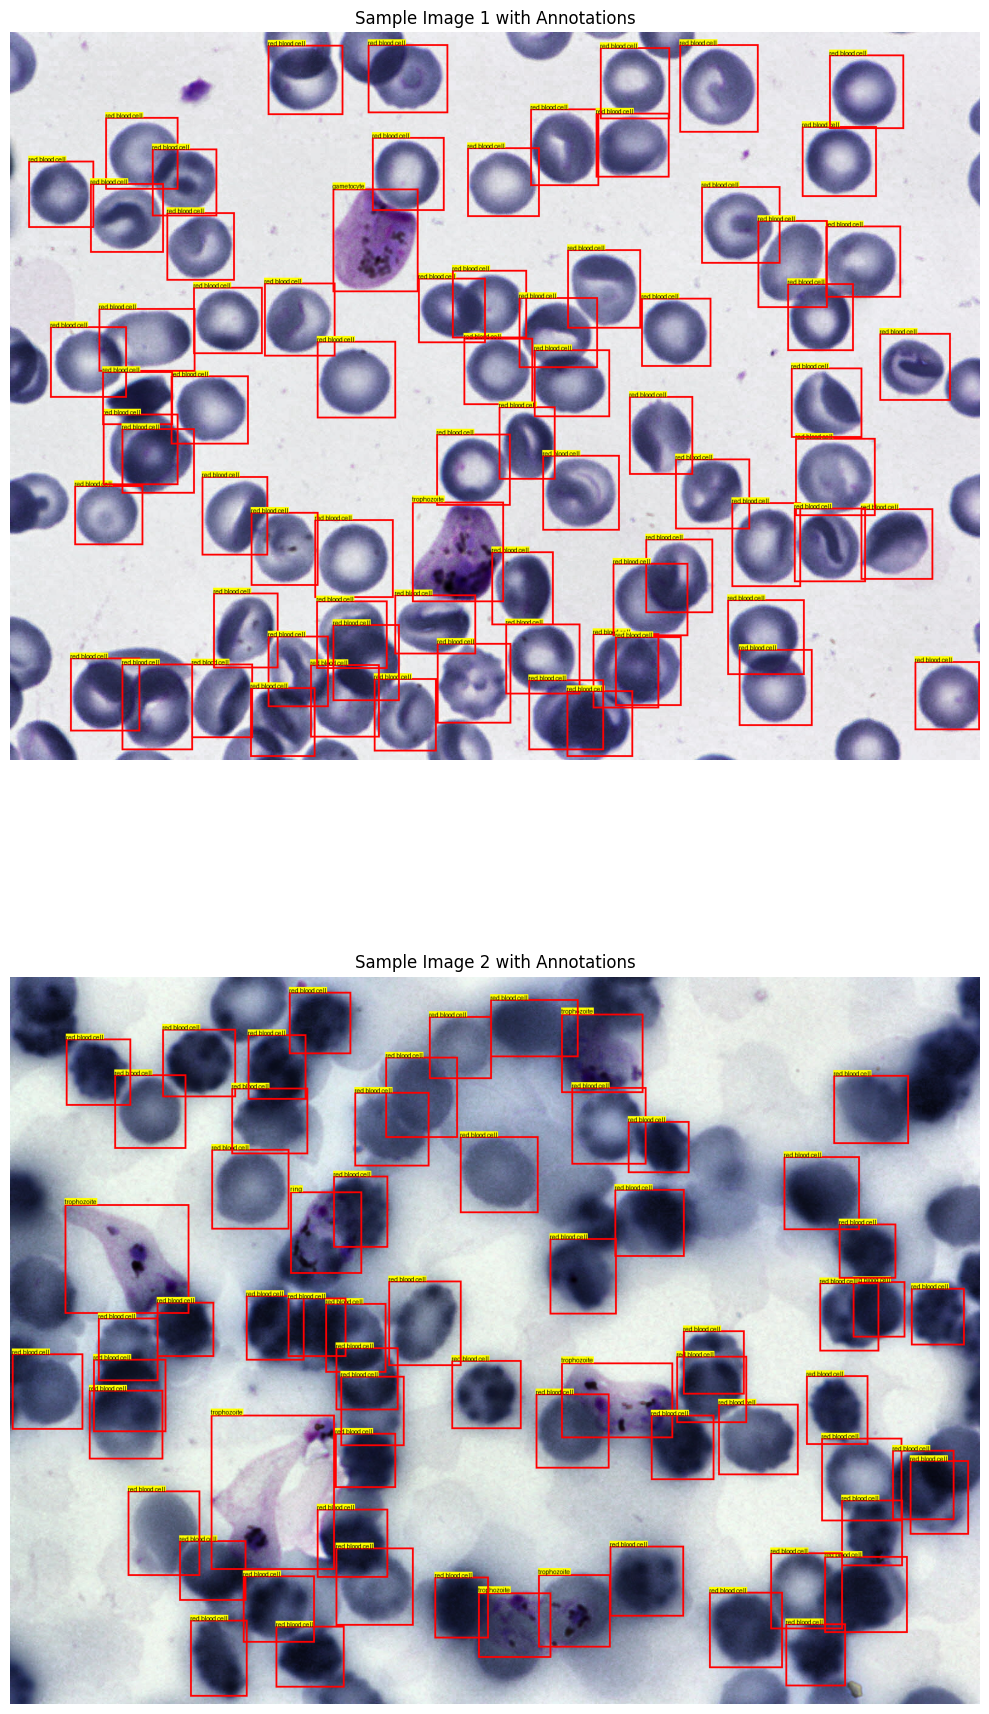

In [ ]:
# Load the training data to get image paths and annotations
train_json_path = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels/train/train.json' # Updated path
try:
    with open(train_json_path, 'r') as f:
        train_data = json.load(f)
except FileNotFoundError:
    print(f"Error: The file {train_json_path} was not found.")
    train_data = []
except json.JSONDecodeError:
    print(f"Error: Could not decode JSON from {train_json_path}. Please check the file format.")
    train_data = []
except Exception as e:
    print(f"An error occurred: {e}")
    train_data = []


# Select 2 random entries from the training data
num_images_to_display = 2
if len(train_data) >= num_images_to_display:
    sample_entries = random.sample(train_data, num_images_to_display)
else:
    sample_entries = train_data
    num_images_to_display = len(sample_entries)


image_dir = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/images/train'

plt.figure(figsize=(10, 10 * num_images_to_display)) # Adjust figure size for vertical layout

for i, entry in enumerate(sample_entries):
    image_pathname = os.path.basename(entry['image']['pathname']) # Get just the filename
    # Construct the full image path by joining the corrected base directory and the filename
    image_path = os.path.join(image_dir, image_pathname)


    try:
        img = Image.open(image_path).convert("RGB") # Convert to RGB to ensure compatibility with drawing
        draw = ImageDraw.Draw(img)

        # Draw bounding boxes and labels
        for obj in entry['objects']:
            bbox = obj['bounding_box']
            category = obj['category']
            # The JSON uses 'c' for column (x) and 'r' for row (y)
            # PIL's bounding box is (x_min, y_min, x_max, y_max)
            x_min = bbox['minimum']['c']
            y_min = bbox['minimum']['r']
            x_max = bbox['maximum']['c']
            y_max = bbox['maximum']['r']

            # Draw rectangle
            draw.rectangle([(x_min, y_min), (x_max, y_max)], outline="red", width=3)

            # Draw label background
            text_color = "black"
            box_color = "yellow"
            try:
                # Attempt to use a common font
                font = ImageFont.truetype("arial.ttf", 20)
            except IOError:
                # Fallback to default PIL font if arial.ttf is not available
                font = ImageFont.load_default()


            # Use textbbox instead of textsize
            text_bbox = draw.textbbox((x_min, y_min), category, font=font)
            text_width = text_bbox[2] - text_bbox[0]
            text_height = text_bbox[3] - text_bbox[1]

            text_box_coords = [(x_min, y_min - text_height), (x_min + text_width, y_min)]
            draw.rectangle(text_box_coords, fill=box_color)

            # Draw label text
            draw.text((x_min, y_min - text_height), category, fill=text_color, font=font)


        plt.subplot(num_images_to_display, 1, i + 1) # display one image per row
        plt.imshow(img)
        plt.title(f"Sample Image {i+1} with Annotations")
        plt.axis('off') # Hide axes for cleaner image display

    except FileNotFoundError:
        print(f"Error: Image file not found at {image_path}")
    except Exception as e:
        print(f"An error occurred while processing image {image_path}: {e}")

plt.tight_layout()
plt.show()

### **1.5.5 Check for mislabelled images**

In [ ]:
# check distribution of classes in train images
# Assuming train_data is already available from a previous cell's execution
# If not, load it first
if 'train_data' not in locals():
    train_json_path = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels/train/train.json' # Updated path
    try:
        with open(train_json_path, 'r') as f:
            train_data = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file {train_json_path} was not found. Cannot analyze class distribution.")
        train_data = []
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {train_json_path}. Cannot analyze class distribution.")
        train_data = []
    except Exception as e:
        print(f"An error occurred: {e}. Cannot analyze class distribution.")
        train_data = []


# Collect all object categories
categories_list = []
for entry in train_data:
    for obj in entry['objects']:
        categories_list.append(obj['category'])

# Count the occurrences of each category
category_counts = Counter(categories_list)

print("Unique labels found in train dataset:", sorted(set(categories_list)))

# If you expect only these categories:
expected_labels = {'difficult','gametocyte','leukocyte', 'red blood cell', 'ring', 'schizont', 'trophozoite'}

# Check for unexpected labels
unexpected = [c for c in sorted(set(categories_list)) if c not in expected_labels]
if unexpected:
    print("Found unexpected or misspelled categories:", unexpected)
else:
    print("All labels match expected categories.")

Unique labels found in train dataset: ['difficult', 'gametocyte', 'leukocyte', 'red blood cell', 'ring', 'schizont', 'trophozoite']
All labels match expected categories.


In [ ]:
# check distribution of classes in test images
# Assuming test_data is already available from a previous cell's execution
# If not, load it first
if 'test_data' not in locals():
    test_json_path = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels/test.json' # Updated path
    try:
        with open(test_json_path, 'r') as f:
            test_data = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file {test_json_path} was not found. Cannot analyze class distribution.")
        test_data = []
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {test_json_path}. Cannot analyze class distribution.")
        test_data = []
    except Exception as e:
        print(f"An error occurred: {e}. Cannot analyze class distribution.")
        test_data = []

# Collect all object categories
categories_list = []
for entry in test_data:
    for obj in entry['objects']:
        categories_list.append(obj['category'])

# Count the occurrences of each category
category_counts = Counter(categories_list)

print("Unique labels found in test dataset:", sorted(set(categories_list)))


# If you expect only these categories:
expected_labels = {'difficult','gametocyte','leukocyte', 'red blood cell', 'ring', 'schizont', 'trophozoite'}

# Check for unexpected labels
unexpected = [c for c in sorted(set(categories_list)) if c not in expected_labels]
if unexpected:
    print("Found unexpected or misspelled categories:", unexpected)
else:
    print("All labels match expected categories.")

Unique labels found in test dataset: ['difficult', 'gametocyte', 'red blood cell', 'ring', 'schizont', 'trophozoite']
All labels match expected categories.


In [ ]:
# check distribution of classes in validation images
# Assuming val_data is already available from a previous cell's execution
# If not, load it first
if 'val_data' not in locals():
    val_json_path = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels/val/val.json' # Correct path for val.json
    try:
        with open(val_json_path, 'r') as f:
            val_data = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file {val_json_path} was not found. Cannot analyze class distribution.")
        val_data = []
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {val_json_path}. Please check the file format.")
        val_data = []
    except Exception as e:
        print(f"An error occurred: {e}. Cannot analyze class distribution.")
        val_data = []

# Collect all object categories
categories_list = []
for entry in val_data:
    for obj in entry['objects']:
        categories_list.append(obj['category'])

# Count the occurrences of each category
category_counts = Counter(categories_list)

print("Unique labels found in validation dataset:", sorted(set(categories_list)))


# If you expect only these categories:
expected_labels = {'difficult','gametocyte','leukocyte', 'red blood cell', 'ring', 'schizont', 'trophozoite'}

# Check for unexpected labels
unexpected = [c for c in sorted(set(categories_list)) if c not in expected_labels]
if unexpected:
    print("Found unexpected or misspelled categories:", unexpected)
else:
    print("All labels match expected categories.")

Unique labels found in validation dataset: ['difficult', 'gametocyte', 'leukocyte', 'red blood cell', 'ring', 'schizont', 'trophozoite']
All labels match expected categories.


### **1.5.6 Check for any bounding box issues**

In [ ]:
bad_boxes = []

for img_data in test_data:
    img_name = os.path.basename(img_data["image"]["pathname"])
    w = img_data["image"]["shape"]["c"]
    h = img_data["image"]["shape"]["r"]
    for obj in img_data["objects"]:
        box = obj["bounding_box"]
        xmin, ymin = box["minimum"]["c"], box["minimum"]["r"]
        xmax, ymax = box["maximum"]["c"], box["maximum"]["r"]
        if xmin >= xmax or ymin >= ymax:
            bad_boxes.append((img_name, "zero or negative box size"))
        elif xmin < 0 or ymin < 0 or xmax > w or ymax > h:
            bad_boxes.append((img_name, "box outside image bounds"))

print(f" Found {len(bad_boxes)} bounding box issues in test data.")
if bad_boxes:
    for i, (img, issue) in enumerate(bad_boxes[:10]):
        print(f"{i+1}. {img} → {issue}")

 Found 0 bounding box issues in test data.


In [ ]:
bad_boxes = []

for img_data in train_data:
    img_name = os.path.basename(img_data["image"]["pathname"])
    w = img_data["image"]["shape"]["c"]
    h = img_data["image"]["shape"]["r"]
    for obj in img_data["objects"]:
        box = obj["bounding_box"]
        xmin, ymin = box["minimum"]["c"], box["minimum"]["r"]
        xmax, ymax = box["maximum"]["c"], box["maximum"]["r"]
        if xmin >= xmax or ymin >= ymax:
            bad_boxes.append((img_name, "zero or negative box size"))
        elif xmin < 0 or ymin < 0 or xmax > w or ymax > h:
            bad_boxes.append((img_name, "box outside image bounds"))

print(f" Found {len(bad_boxes)} bounding box issues in train data.")
if bad_boxes:
    for i, (img, issue) in enumerate(bad_boxes[:10]):
        print(f"{i+1}. {img} → {issue}")

 Found 0 bounding box issues in train data.


In [ ]:
# Check for bounding box issues in validation data
bad_boxes = []

# Assuming val_data is available from previous cell executions
if 'val_data' not in locals():
    val_json_path = '/content/drive/MyDrive/malaria_dataset_3/malaria_emalaria_extracted_3xtracted/malaria/labels/val/val.json' # Correct path for val.json
    try:
        with open(val_json_path, 'r') as f:
            val_data = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file {val_json_path} was not found. Cannot check for bounding box issues.")
        val_data = []
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {val_json_path}. Please check the file format.")
        val_data = []
    except Exception as e:
        print(f"An error occurred: {e}. Cannot check for bounding box issues.")
        val_data = []


for img_data in val_data:
    img_name = os.path.basename(img_data["image"]["pathname"])
    # Need to get image dimensions from the image file for validation data
    # Since the JSON doesn't store shape directly for validation images after moving
    image_path = os.path.join('/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/images/val', img_name)
    try:
        with Image.open(image_path) as img:
            w, h = img.size
    except FileNotFoundError:
        print(f"Warning: Image file not found for {img_name} at {image_path}. Cannot validate its bounding boxes.")
        continue # Skip this image if file not found
    except Exception as e:
        print(f"Error opening image file {image_path}: {e}. Cannot validate its bounding boxes.")
        continue


    for obj in img_data["objects"]:
        box = obj["bounding_box"]
        xmin, ymin = box["minimum"]["c"], box["minimum"]["r"]
        xmax, ymax = box["maximum"]["c"], box["maximum"]["r"]
        if xmin >= xmax or ymin >= ymax:
            bad_boxes.append((img_name, "zero or negative box size"))
        elif xmin < 0 or ymin < 0 or xmax > w or ymax > h:
            bad_boxes.append((img_name, "box outside image bounds"))

print(f" Found {len(bad_boxes)} bounding box issues in validation data.")
if bad_boxes:
    for i, (img, issue) in enumerate(bad_boxes[:10]):
        print(f"{i+1}. {img} → {issue}")

 Found 0 bounding box issues in validation data.


### **1.5.7 Detect duplicate boxes on the same objec**t

In [ ]:
duplicates = []
for img_data in train_data:
    seen = set()
    img_name = os.path.basename(img_data["image"]["pathname"])
    for obj in img_data["objects"]:
        box = obj["bounding_box"]
        coords = (
            box["minimum"]["c"], box["minimum"]["r"],
            box["maximum"]["c"], box["maximum"]["r"]
        )
        if coords in seen:
            duplicates.append(img_name)
        else:
            seen.add(coords)

duplicates = list(set(duplicates))
print(f" Found {len(duplicates)} images with duplicate bounding boxes in train subset.")
if duplicates:
    print("Examples:", duplicates[:10])

 Found 0 images with duplicate bounding boxes in train subset.


In [ ]:
duplicates = []
for img_data in test_data:
    seen = set()
    img_name = os.path.basename(img_data["image"]["pathname"])
    for obj in img_data["objects"]:
        box = obj["bounding_box"]
        coords = (
            box["minimum"]["c"], box["minimum"]["r"],
            box["maximum"]["c"], box["maximum"]["r"]
        )
        if coords in seen:
            duplicates.append(img_name)
        else:
            seen.add(coords)

duplicates = list(set(duplicates))
print(f" Found {len(duplicates)} images with duplicate bounding boxes in test subset.")
if duplicates:
    print("Examples:", duplicates[:10])

 Found 0 images with duplicate bounding boxes in test subset.


In [ ]:
duplicates = []
for img_data in val_data:
    seen = set()
    img_name = os.path.basename(img_data["image"]["pathname"])
    for obj in img_data["objects"]:
        box = obj["bounding_box"]
        coords = (
            box["minimum"]["c"], box["minimum"]["r"],
            box["maximum"]["c"], box["maximum"]["r"]
        )
        if coords in seen:
            duplicates.append(img_name)
        else:
            seen.add(coords)

duplicates = list(set(duplicates))
print(f" Found {len(duplicates)} images with duplicate bounding boxes in val subset.")
if duplicates:
    print("Examples:", duplicates[:10])

 Found 0 images with duplicate bounding boxes in val subset.


### **1.5.8 Check for class imbalance**

Object category distribution in training data:
Counter({'red blood cell': 59967,
         'trophozoite': 1124,
         'difficult': 338,
         'ring': 273,
         'schizont': 130,
         'gametocyte': 109,
         'leukocyte': 81})


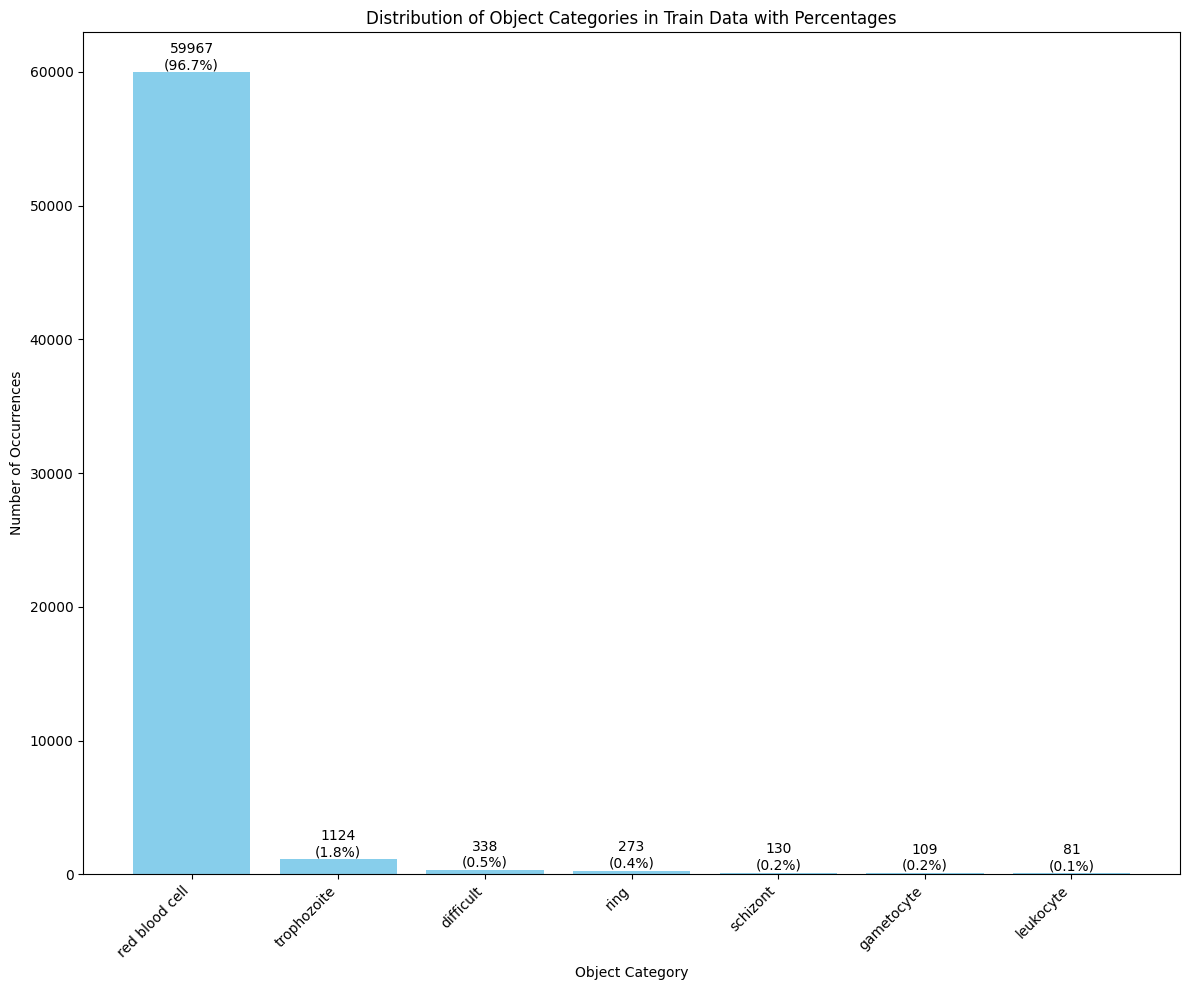

In [ ]:
# check distribution of classes in train images
# Assuming train_data is already available from a previous cell's execution
# If not, load it first
if 'train_data' not in locals():
    train_json_path = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels/train/train.json'
    try:
        with open(train_json_path, 'r') as f:
            train_data = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file {train_json_path} was not found. Cannot analyze class distribution.")
        train_data = []
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {train_json_path}. Cannot analyze class distribution.")
        train_data = []
    except Exception as e:
        print(f"An error occurred: {e}. Cannot analyze class distribution.")
        train_data = []


# Collect all object categories
categories_list = []
for entry in train_data:
    for obj in entry['objects']:
        categories_list.append(obj['category'])

# Count the occurrences of each category
category_counts = Counter(categories_list)

print("Object category distribution in training data:")
pprint(category_counts)

# Sort categories and counts in descending order of counts
sorted_counts = dict(category_counts.most_common())
categories = list(sorted_counts.keys())
counts = list(sorted_counts.values())

# Calculate total count for percentages
total_count = sum(counts)

# Create a bar plot
plt.figure(figsize=(12, 10))
bars = plt.bar(categories, counts, color='skyblue')
plt.xlabel("Object Category")
plt.ylabel("Number of Occurrences")
plt.title("Distribution of Object Categories in Train Data with Percentages")
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

# Add text annotations for counts and percentages
for bar in bars:
    yval = bar.get_height()
    percentage = (yval / total_count) * 100 if total_count > 0 else 0
    plt.text(bar.get_x() + bar.get_width()/2, yval,
             f'{yval}\n({percentage:.1f}%)',
             va='bottom', ha='center', rotation=0, fontsize=10) # Adjust va, ha, rotation, and fontsize as needed

plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

**Red blood cells** are the most frequent category, making up a very large percentage of the total objects.

The next most frequent category is **trophozoite**, but its count is significantly lower than that of red blood cells.

The remaining categories, including difficult, ring, schizont, gametocyte, and leukocyte, have much lower counts compared to red blood cells and trophozoites.

There is **imbalance in the dataset** at the object level with a disproportionately high number of red blood cells compared to the other categories, especially the different stages of the malaria parasite (trophozoite, ring, schizont, gametocyte). Therefore this imbalance will have to be handled before model training to ensure the model can effectively detect the less frequent classes.

A combination of data augmentation and use of weighted loss function or Focal Loss will likely be effective strategies.

Object category distribution in testing data:
Counter({'red blood cell': 5614,
         'ring': 169,
         'trophozoite': 111,
         'gametocyte': 12,
         'schizont': 11,
         'difficult': 5})


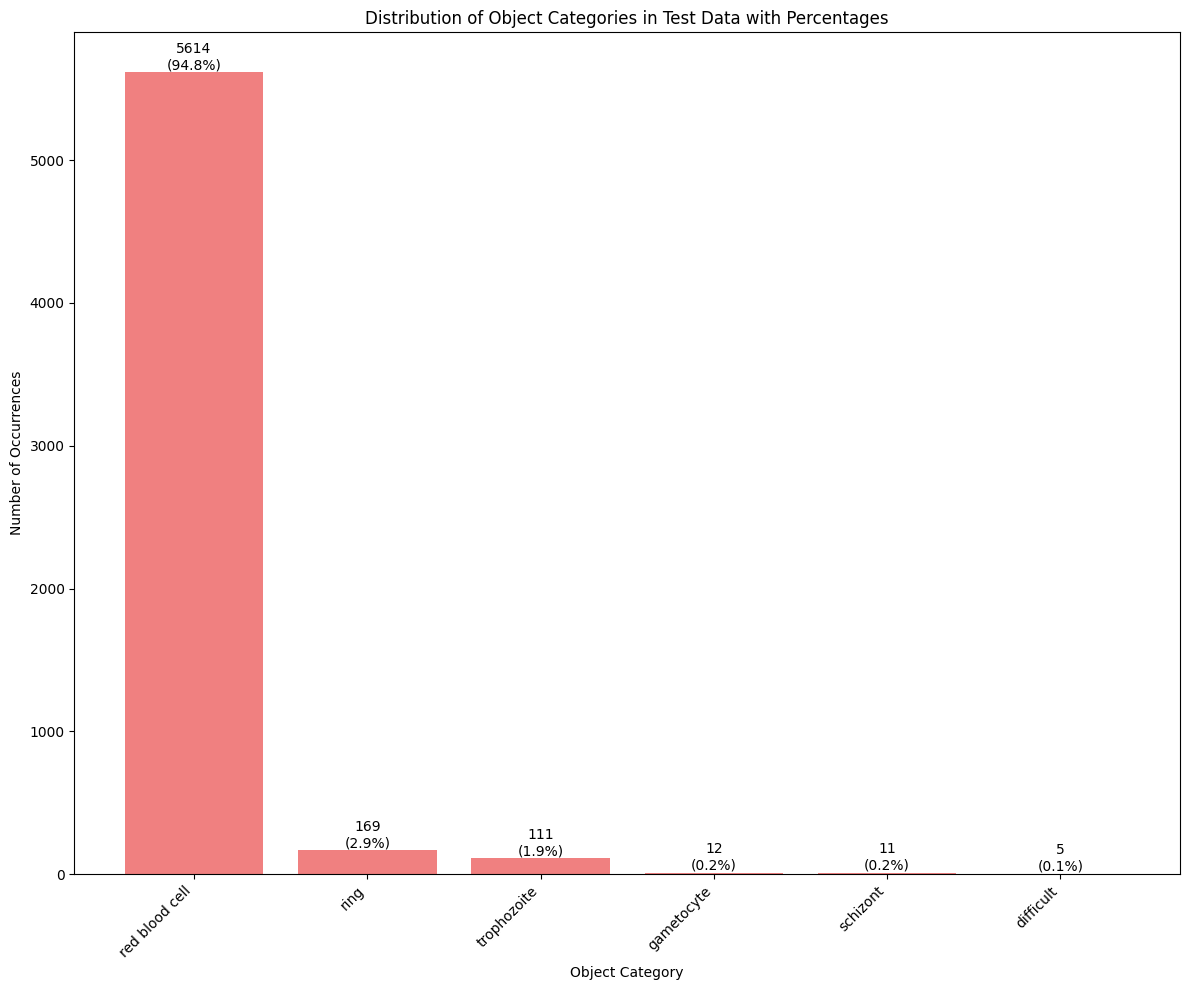

In [ ]:
# Assuming test_data is already available from a previous cell's execution
# If not, load it first
if 'test_data' not in locals():
    test_json_path = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels/test/test.json'
    try:
        with open(test_json_path, 'r') as f:
            test_data = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file {test_json_path} was not found. Cannot analyze class distribution.")
        test_data = []
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {test_json_path}. Cannot analyze class distribution.")
        test_data = []
    except Exception as e:
        print(f"An error occurred: {e}. Cannot analyze class distribution.")
        test_data = []

# Collect all object categories
categories_list = []
for entry in test_data:
    for obj in entry['objects']:
        categories_list.append(obj['category'])

# Count the occurrences of each category
category_counts = Counter(categories_list)

print("Object category distribution in testing data:")
pprint(category_counts)

# Optional: Create a bar plot for test data distribution
if category_counts:
    # Sort categories and counts in descending order of counts
    sorted_counts = dict(category_counts.most_common())
    categories = list(sorted_counts.keys())
    counts = list(sorted_counts.values())

    # Calculate total count for percentages
    total_count = sum(counts)

    plt.figure(figsize=(12, 10))
    bars = plt.bar(categories, counts, color='lightcoral')
    plt.xlabel("Object Category")
    plt.ylabel("Number of Occurrences")
    plt.title("Distribution of Object Categories in Test Data with Percentages")
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

    # Add text annotations for counts and percentages
    for bar in bars:
        yval = bar.get_height()
        percentage = (yval / total_count) * 100 if total_count > 0 else 0
        plt.text(bar.get_x() + bar.get_width()/2, yval,
                 f'{yval}\n({percentage:.1f}%)',
                 va='bottom', ha='center', rotation=0, fontsize=10) # Adjust va, ha, rotation, and fontsize as needed

    plt.tight_layout() # Adjust layout to prevent labels overlapping
    plt.show()
else:
    print("No object categories found in test data to plot.")

The plot for the test data distribution, similar to the training data, shows a significant class imbalance.

Red blood cells are the most numerous category by a large margin, similar to the training data.
The counts for the other categories (ring, trophozoite, gametocyte, schizont, and difficult) are considerably lower than that of red blood cells.
The malaria parasite stages (ring, trophozoite, gametocyte, and schizont) are minority classes in the test set as well.
The category 'leukocyte' is present in the training data but appears to be absent in the test data, or its count is very low (it's not shown in the plotted categories, likely due to having 0 or very few instances).

Object category distribution in validation data:
Counter({'red blood cell': 17291,
         'trophozoite': 293,
         'difficult': 101,
         'ring': 84,
         'gametocyte': 42,
         'schizont': 37,
         'leukocyte': 27})


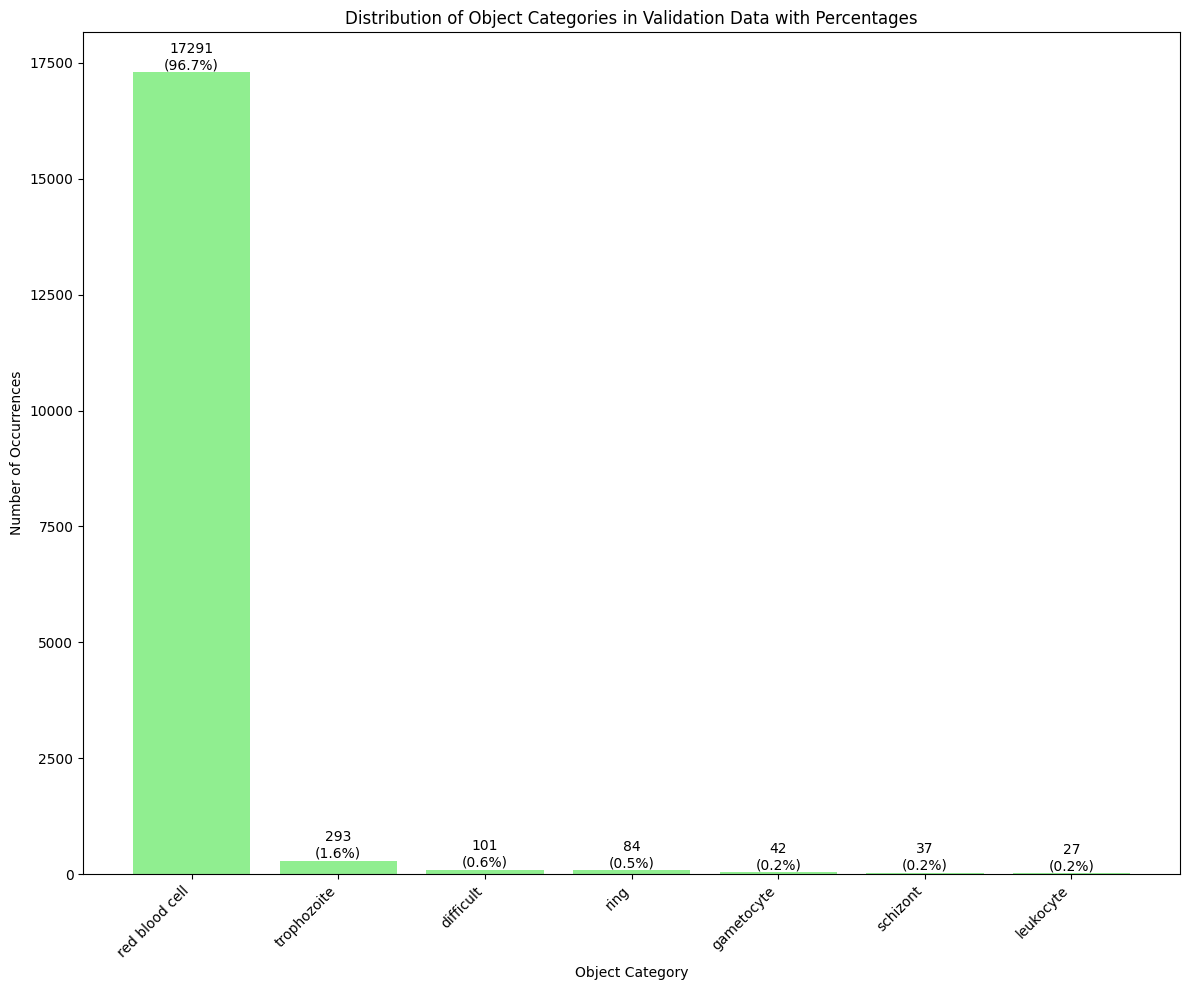

In [ ]:
# check distribution of classes in validation images
# Assuming val_data is already available from a previous cell's execution
# If not, load it first
if 'val_data' not in locals():
    val_json_path = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels/val/val.json' # Correct path for val.json
    try:
        with open(val_json_path, 'r') as f:
            val_data = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file {val_json_path} was not found. Cannot analyze class distribution.")
        val_data = []
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {val_json_path}. Please check the file format.")
        val_data = []
    except Exception as e:
        print(f"An error occurred: {e}. Cannot analyze class distribution.")
        val_data = []

# Collect all object categories
categories_list = []
for entry in val_data:
    for obj in entry['objects']:
        categories_list.append(obj['category'])

# Count the occurrences of each category
category_counts = Counter(categories_list)

print("Object category distribution in validation data:")
pprint(category_counts)

# Optional: Create a bar plot for validation data distribution
if category_counts:
    # Sort categories and counts in descending order of counts
    sorted_counts = dict(category_counts.most_common())
    categories = list(sorted_counts.keys())
    counts = list(sorted_counts.values())

    # Calculate total count for percentages
    total_count = sum(counts)

    plt.figure(figsize=(12, 10))
    bars = plt.bar(categories, counts, color='lightgreen')
    plt.xlabel("Object Category")
    plt.ylabel("Number of Occurrences")
    plt.title("Distribution of Object Categories in Validation Data with Percentages")
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

    # Add text annotations for counts and percentages
    for bar in bars:
        yval = bar.get_height()
        percentage = (yval / total_count) * 100 if total_count > 0 else 0
        plt.text(bar.get_x() + bar.get_width()/2, yval,
                 f'{yval}\n({percentage:.1f}%)',
                 va='bottom', ha='center', rotation=0, fontsize=10) # Adjust va, ha, rotation, and fontsize as needed

    plt.tight_layout() # Adjust layout to prevent labels overlapping
    plt.show()
else:
    print("No object categories found in validation data to plot.")

same comment as for test and train data

## **1.6 Data preprocessing**

### **1.6.1 Convert JSON Annotations to YOLO Format**

In [ ]:
# Step 1: Convert JSON Annotations to YOLO Format

import os
import json
from PIL import Image # Import Image to get image dimensions

# Define the base directory for the dataset in Google Drive
base_dir = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria'

# Define paths to image and label directories
image_dirs = {
    'train': os.path.join(base_dir, 'images', 'train'),
    'val': os.path.join(base_dir, 'images', 'val'),
    'test': os.path.join(base_dir, 'images', 'test')
}

label_json_paths = {
    'train': os.path.join(base_dir, 'labels', 'train', 'train.json'),
    'val': os.path.join(base_dir, 'labels', 'val', 'val.json'),
    'test': os.path.join(base_dir, 'labels', 'test', 'test.json')
}

yolo_label_dirs = {
    'train': os.path.join(base_dir, 'labels', 'train'),
    'val': os.path.join(base_dir, 'labels', 'val'),
    'test': os.path.join(base_dir, 'labels', 'test')
}

# Ensure the YOLO label directories exist
for dataset_type in yolo_label_dirs:
    os.makedirs(yolo_label_dirs[dataset_type], exist_ok=True)


# Define the mapping from category name to class ID
# Ensure the order matches the desired class order for YOLOv8
class_mapping = {
    'red blood cell': 0,
    'trophozoite': 1,
    'ring': 2,
    'schizont': 3,
    'gametocyte': 4,
    'leukocyte': 5,
    'difficult': 6 # 'difficult' objects are often included but might be ignored during training/evaluation depending on configuration
}

print("Starting annotation conversion to YOLO format...")


for dataset_type, json_path in label_json_paths.items():
    print(f"\nConverting annotations for {dataset_type} dataset...")
    try:
        with open(json_path, 'r') as f:
            annotations_data = json.load(f)
    except FileNotFoundError:
        print(f"Error: Annotation file not found at {json_path}. Skipping {dataset_type} conversion.")
        continue
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {json_path}. Skipping {dataset_type} conversion.")
        continue
    except Exception as e:
        print(f"An error occurred loading {json_path}: {e}. Skipping {dataset_type} conversion.")
        continue


    image_count = 0
    for entry in annotations_data:
        image_pathname = os.path.basename(entry['image']['pathname'])
        image_path = os.path.join(image_dirs[dataset_type], image_pathname)

        # Get image dimensions
        try:
            with Image.open(image_path) as img:
                img_w, img_h = img.size
        except FileNotFoundError:
            print(f"Warning: Image file not found for {image_pathname} at {image_path}. Skipping its annotations.")
            continue
        except Exception as e:
            print(f"Error opening image file {image_path}: {e}. Skipping its annotations.")
            continue

        # Define the path for the YOLO format label file
        label_filename = os.path.splitext(image_pathname)[0] + '.txt'
        yolo_label_path = os.path.join(yolo_label_dirs[dataset_type], label_filename)

        # Write annotations to the YOLO format file
        with open(yolo_label_path, 'w') as f:
            for obj in entry.get('objects', []):
                category = obj['category']
                bbox = obj['bounding_box']

                # Get class ID
                class_id = class_mapping.get(category)
                if class_id is None:
                    print(f"Warning: Unknown category '{category}' in {image_pathname}. Skipping object.")
                    continue # Skip object if category is not in mapping

                # Get bounding box coordinates
                xmin = bbox['minimum']['c']
                ymin = bbox['minimum']['r']
                xmax = bbox['maximum']['c']
                ymax = bbox['maximum']['r']

                # Calculate YOLO format coordinates (normalized center_x, center_y, width, height)
                center_x = (xmin + xmax) / 2.0
                center_y = (ymin + ymax) / 2.0
                width = xmax - xmin
                height = ymax - ymin

                # Normalize coordinates
                # Ensure image dimensions are not zero to avoid division by zero
                if img_w > 0 and img_h > 0:
                    center_x_norm = center_x / img_w
                    center_y_norm = center_y / img_h
                    width_norm = width / img_w
                    height_norm = height / img_h

                    # Write to file in YOLO format
                    f.write(f"{class_id} {center_x_norm:.6f} {center_y_norm:.6f} {width_norm:.6f} {height_norm:.6f}\n")
                else:
                    print(f"Warning: Image {image_pathname} has zero dimensions. Cannot normalize bounding boxes. Skipping annotations for this image.")


        image_count += 1
    print(f"Converted annotations for {image_count} images in the {dataset_type} dataset.")

print("\nAnnotation conversion complete.")

Starting annotation conversion to YOLO format...

Converting annotations for train dataset...
Converted annotations for 939 images in the train dataset.

Converting annotations for val dataset...
Converted annotations for 269 images in the val dataset.

Converting annotations for test dataset...
Converted annotations for 120 images in the test dataset.

Annotation conversion complete.


### **1.6.2 Creation of YOLO Data Configuration File**

In [ ]:
# Step 1: Create YOLO Data Configuration File

import yaml
import os

# Define the base directory for the dataset in Google Drive
base_dir = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria'

# Define the paths for the train and validation image and label directories
train_img_dir = os.path.join(base_dir, 'images', 'train')
val_img_dir = os.path.join(base_dir, 'images', 'val')
train_label_dir = os.path.join(base_dir, 'labels', 'train')
val_label_dir = os.path.join(base_dir, 'labels', 'val')

# Define the class names in the desired order (matching the class_mapping used in the conversion script)
class_names = ['red blood cell', 'trophozoite', 'ring', 'schizont', 'gametocyte', 'leukocyte', 'difficult']
num_classes = len(class_names)

# Create the data dictionary for the YAML file
data = {
    'train': train_img_dir,
    'val': val_img_dir,
    'nc': num_classes,  # Number of classes
    'names': class_names # List of class names
}

# Check if class_weights_array is available and add it to the data dictionary
if 'class_weights_array' in locals() and class_weights_array:
    data['cls_weights'] = class_weights_array
    print("✅ Added class weights to the YAML data dictionary.")
else:
    print("⚠️ class_weights_array not found. Class weights will not be added to the YAML unless defined elsewhere.")


# Define the path where the YAML file will be saved in Google Drive
yaml_file_path = os.path.join(base_dir, 'malaria_dataset_3.yaml')

try:
    with open(yaml_file_path, 'w') as f:
        yaml.dump(data, f, default_flow_style=False)
    print(f" YOLO data configuration (with potentially added weights) saved at: {yaml_file_path}")
except Exception as e:
    print(f"Error creating YOLO data configuration file: {e}")

✅ Added class weights to the YAML data dictionary.
 YOLO data configuration (with potentially added weights) saved at: /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/malaria_dataset_3.yaml


In [ ]:
# show the content of the YAML file

# Define the path to the YAML file in Google Drive
yaml_file_path = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/malaria_dataset_3.yaml'

# Read and print the content of the YAML file
try:
    with open(yaml_file_path, 'r') as f:
        yaml_content = f.read()
    print(yaml_content)
except FileNotFoundError:
    print(f"Error: The file {yaml_file_path} was not found.")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")

cls_weights:
- 0.01
- 0.32
- 1.65
- 4.58
- 4.28
- 4.44
- 1.39
names:
- red blood cell
- trophozoite
- ring
- schizont
- gametocyte
- leukocyte
- difficult
nc: 7
train: /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/images/train
val: /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/images/val



### **1.6.3 Selective oversampling of images with minority classes: handling class imbalance**

In [ ]:
# check how many train images have red blood cells only.
import json
import os

# Assuming train_data is available from a previous cell's execution
# If not, load it first
if 'train_data' not in locals() or not train_data:
    train_json_path = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels/train/train.json'
    try:
        with open(train_json_path, 'r') as f:
            train_data = json.load(f)
    except FileNotFoundError:
        print(f"Error: The file {train_json_path} was not found. Cannot count images with only red blood cells.")
        train_data = []
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {train_json_path}. Cannot count images with only red blood cells.")
        train_data = []
    except Exception as e:
        print(f"An error occurred: {e}. Cannot count images with only red blood cells.")
        train_data = []

if train_data:
    red_blood_cell_only_count = 0

    for entry in train_data:
        # Get the categories present in the current image
        categories_in_image = set()
        for obj in entry.get('objects', []):
            categories_in_image.add(obj['category'])

        # Check if the image contains only 'red blood cell' and at least one object
        if 'red blood cell' in categories_in_image and len(categories_in_image) == 1:
             # Ensure there is at least one object to count as "only red blood cells"
             if len(entry.get('objects', [])) > 0:
                red_blood_cell_only_count += 1


    print(f"Number of training images with only red blood cells: {red_blood_cell_only_count}")

else:
    print("No training data available to count images with only red blood cells.")

Number of training images with only red blood cells: 141


In [ ]:
import json
import os
from collections import Counter # Import Counter

# Define the base directory for the dataset in Google Drive
base_dir = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria'

# Define paths to the training label directory and json file
train_label_dir = os.path.join(base_dir, 'labels', 'train')
train_json_path = os.path.join(train_label_dir, 'train.json')

# Define minority classes (should match the oversampling code)
minority_classes = ['trophozoite', 'ring', 'schizont', 'gametocyte', 'leukocyte','difficult']

# Load the training data
try:
    with open(train_json_path, 'r') as f:
        train_data = json.load(f)
except FileNotFoundError:
    print(f"Error: The file {train_json_path} was not found. Cannot count images.")
    train_data = []
except json.JSONDecodeError:
    print(f"Error: Could not decode JSON from {train_json_path}. Cannot count images.")
    train_data = []
except Exception as e:
    print(f"An error occurred loading {train_json_path}: {e}. Cannot count images.")
    train_data = []

if train_data:
    images_with_2_or_more_minority_instances = 0
    min_minority_instances_threshold = 2 # Minimum number of minority class instances required in an image

    for entry in train_data:
        minority_instance_count = 0
        for obj in entry.get('objects', []):
            category = obj['category']
            if category in minority_classes:
                minority_instance_count += 1

        # Check if the image has two or more minority instances
        if minority_instance_count >= min_minority_instances_threshold:
             images_with_2_or_more_minority_instances += 1

    print(f"Number of training images with {min_minority_instances_threshold} or more minority class instances: {images_with_2_or_more_minority_instances}")

else:
    print("No training data available to count images.")

Number of training images with 2 or more minority class instances: 485


In [ ]:
import os
import json
import shutil
import random
from collections import Counter, defaultdict # Import defaultdict

# Define the base directory for the dataset in Google Drive
base_dir = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria'

# Define paths to the training image and label directories
train_image_dir = os.path.join(base_dir, 'images', 'train')
train_label_dir = os.path.join(base_dir, 'labels', 'train')
train_json_path = os.path.join(train_label_dir, 'train.json')


# Define the class mapping (should match the one used for YOLO conversion)
class_mapping = {
    'red blood cell': 0,
    'trophozoite': 1,
    'ring': 2,
    'schizont': 3,
    'gametocyte': 4,
    'leukocyte': 5,
    'difficult': 6
}

# Define minority classes (based on your class distribution analysis)
# Exclude 'red blood cell' as it's the majority class
minority_classes = ['trophozoite', 'ring', 'schizont', 'gametocyte', 'leukocyte', 'difficult'] # Adjust based on your specific needs


# Load the original training data (before any oversampling additions)
# It's important to load the original data to avoid duplicating already oversampled images
# Assuming the train.json was updated with oversampled data previously, we need to reload the original state if possible
# A safer approach might be to keep a copy of the original train.json or filter the loaded data.
# For this modification, I will assume the train.json might contain previous oversamples and filter them out for the oversampling selection.

try:
    with open(train_json_path, 'r') as f:
        current_train_data = json.load(f)
except FileNotFoundError:
    print(f"Error: The file {train_json_path} was not found. Cannot perform oversampling.")
    current_train_data = []
except json.JSONDecodeError:
    print(f"Error: Could not decode JSON from {train_json_path}. Cannot perform oversampling.")
    current_train_data = []
except Exception as e:
    print(f"An error occurred loading {train_json_path}: {e}. Cannot perform oversampling.")
    current_train_data = []

# Filter out previously oversampled entries if they exist in the loaded data
original_train_data = [entry for entry in current_train_data if not os.path.basename(entry['image']['pathname']).startswith('oversampled_')]


if original_train_data:
    print(f"Loaded {len(original_train_data)} original training images for oversampling selection.")

    # Identify images containing minority classes with more than 2 instances of any minority class
    minority_images_to_oversample = defaultdict(list)
    min_minority_instances = 2 # Minimum number of minority class instances required in an image

    for entry in original_train_data:
        image_name = os.path.basename(entry['image']['pathname'])
        minority_instance_count = 0
        for obj in entry.get('objects', []):
            category = obj['category']
            if category in minority_classes:
                minority_instance_count += 1

        # If the image has more than the minimum required minority instances, add it for oversampling
        if minority_instance_count > min_minority_instances:
             minority_images_to_oversample[image_name].append(entry) # Store the entire entry for easy access


    print(f"Found {len(minority_images_to_oversample)} images containing more than {min_minority_instances} minority class instances for oversampling.")

    # Determine the target number of images for minority classes (e.g., match the majority class count or a percentage of it)
    # A simple strategy is to aim for a certain number of instances per minority class.
    # For simplicity here, we'll aim to duplicate images until we have a certain number of minority *images*
    # A more sophisticated approach would balance based on *object* counts.

    # Let's aim to increase the number of minority images to a certain factor (e.g., 2x, 3x)
    oversample_factor = 4 # Duplicate images containing minority classes 2 times

    oversampled_data = list(original_train_data) # Start with the original training data for the new oversampling run

    print(f"Starting oversampling with factor {oversample_factor}...")
    # Iterate through the selected minority images for oversampling
    for image_name, entries in minority_images_to_oversample.items():
        # Duplicate the image and its corresponding label file
        original_image_path = os.path.join(train_image_dir, image_name)
        original_label_path = os.path.join(train_label_dir, os.path.splitext(image_name)[0] + '.txt') # Assuming YOLO .txt labels exist

        if not os.path.exists(original_image_path):
             print(f"Warning: Original image not found at {original_image_path}. Skipping oversampling for this image.")
             continue
        if not os.path.exists(original_label_path):
            print(f"Warning: Original label not found at {original_label_path}. Skipping oversampling for this image.")
            continue


        for i in range(oversample_factor -1): # Duplicate (oversample_factor - 1) times
            new_image_name = f"oversampled_{i}_{image_name}"
            new_label_name = f"oversampled_{i}_{os.path.splitext(image_name)[0]}.txt"

            new_image_path = os.path.join(train_image_dir, new_image_name)
            new_label_path = os.path.join(train_label_dir, new_label_name)

            try:
                shutil.copy(original_image_path, new_image_path)
                shutil.copy(original_label_path, new_label_path)

                # Create a new entry for the oversampled data (optional, primarily for tracking)
                # If you are only using YOLO .txt files for training, you don't strictly need to update the train.json
                # But keeping train_data updated can be useful for analysis later.
                new_entry = entries[0].copy() # Copy one of the entries associated with this image
                new_entry['image']['pathname'] = f"/images/train/{new_image_name}" # Update pathname
                oversampled_data.append(new_entry)

            except Exception as e:
                print(f"Error oversampling image {image_name} (duplicate {i}): {e}")

    print("Oversampling complete.")
    print(f"New number of images in oversampled data list: {len(oversampled_data)}")

    # Update the train.json file with the oversampled data entries
    # This is necessary for subsequent steps that read from the JSON file.
    try:
        with open(train_json_path, 'w') as f:
            json.dump(oversampled_data, f, indent=4)
        print(f"Updated train.json with oversampled data saved to: {train_json_path}")
    except Exception as e:
        print(f"Error saving updated train.json after oversampling: {e}")


    # Verify the new class distribution after oversampling (optional)
    print("\nVerifying new class distribution after oversampling...")
    oversampled_categories_list = []
    for entry in oversampled_data:
        for obj in entry.get('objects', []):
            oversampled_categories_list.append(obj['category'])

    oversampled_category_counts = Counter(oversampled_categories_list)

    print("Object category distribution after oversampling:")
    pprint(oversampled_category_counts)

else:
    print("Cannot perform oversampling as original training data is not loaded.")

Loaded 939 original training images for oversampling selection.
Found 307 images containing more than 2 minority class instances for oversampling.
Starting oversampling with factor 4...
Oversampling complete.
New number of images in oversampled data list: 1860
Updated train.json with oversampled data saved to: /content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels/train/train.json

Verifying new class distribution after oversampling...
Object category distribution after oversampling:
Counter({'red blood cell': 125187,
         'trophozoite': 3812,
         'difficult': 863,
         'ring': 726,
         'gametocyte': 280,
         'leukocyte': 270,
         'schizont': 262})


visualization

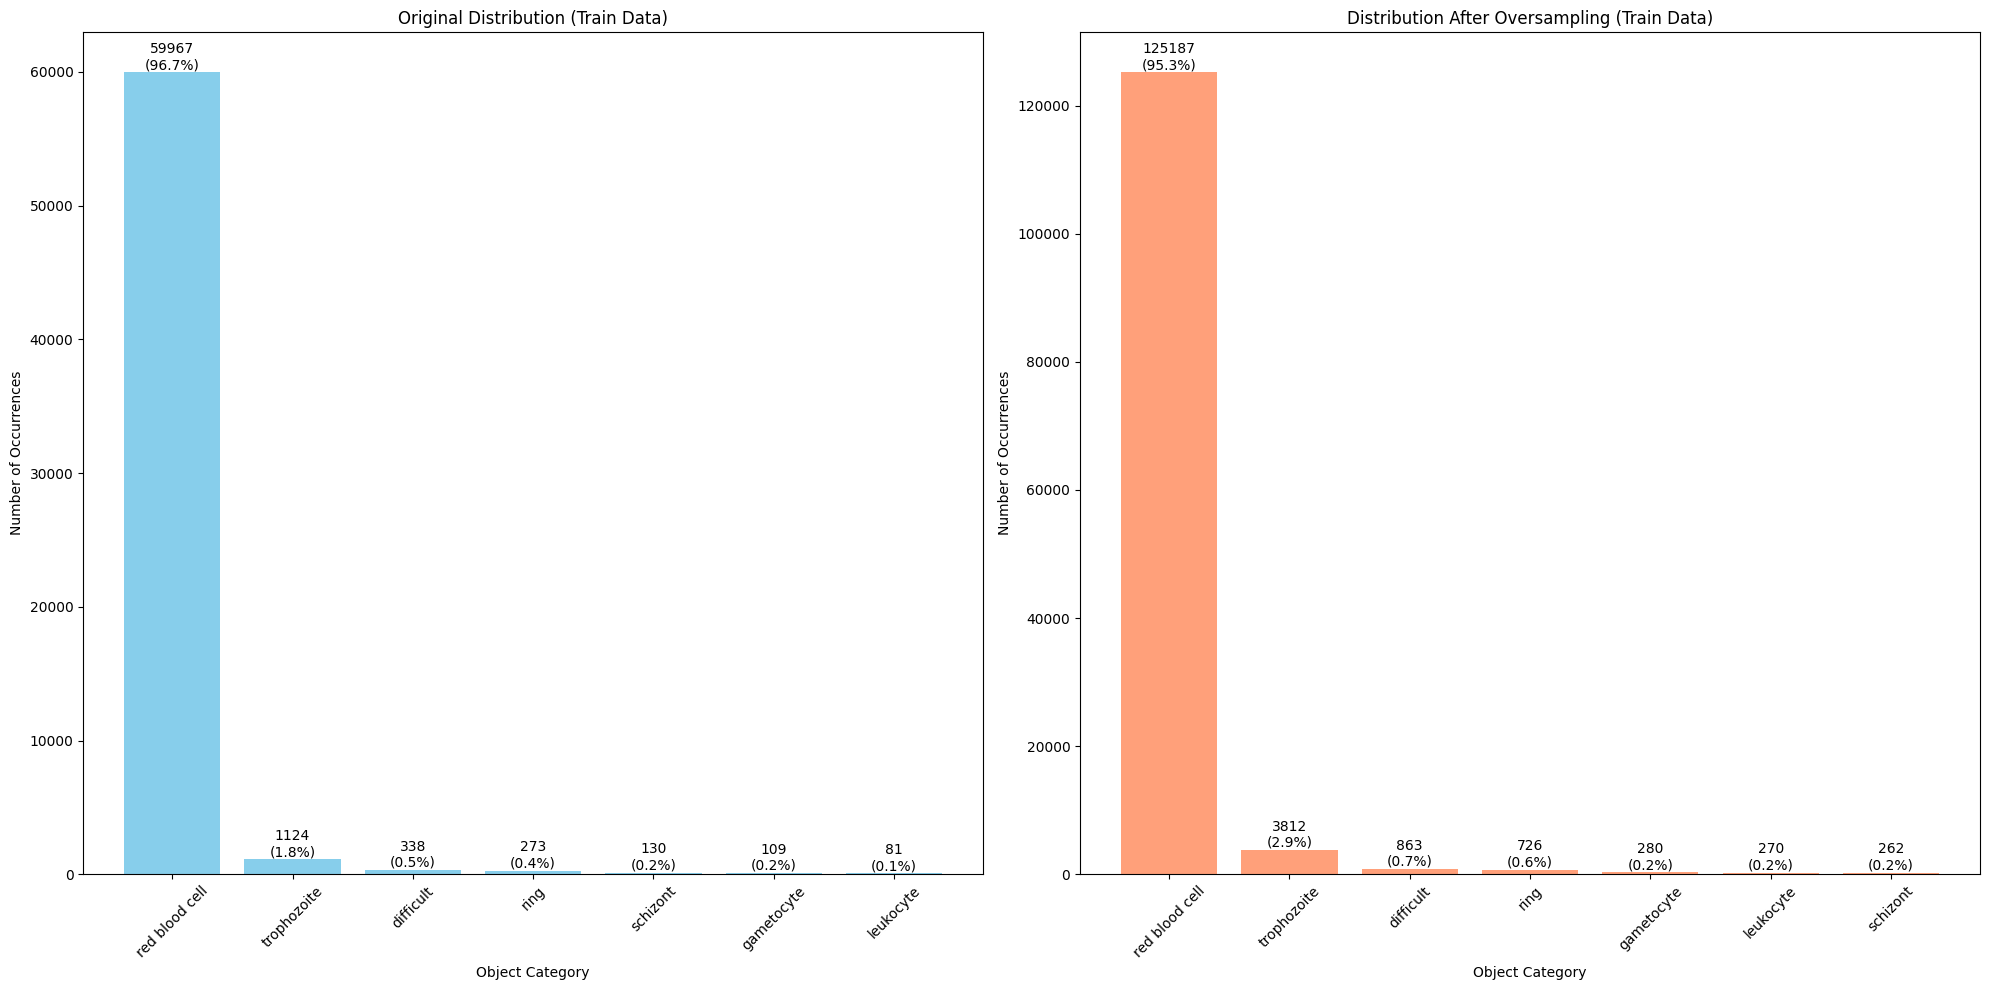

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np
import json
import os

# --- Data Loading (Before Oversampling) ---
# Assuming train_data is available from a previous cell's execution
# If not, load it first
if 'train_data' not in locals():
    train_json_path_original = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels/train/train.json'
    try:
        with open(train_json_path_original, 'r') as f:
            train_data_original = json.load(f)
    except FileNotFoundError:
        print(f"Error: The original train.json file was not found at {train_json_path_original}. Cannot plot original distribution.")
        train_data_original = []
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {train_json_path_original}. Cannot plot original distribution.")
        train_data_original = []
    except Exception as e:
        print(f"An error occurred loading {train_json_path_original}: {e}. Cannot plot original distribution.")
        train_data_original = []
else:
    train_data_original = train_data # Use the train_data variable if it's already loaded

# Collect object categories before oversampling
original_categories_list = []
if train_data_original:
    for entry in train_data_original:
        for obj in entry.get('objects', []):
            original_categories_list.append(obj['category'])
original_category_counts = Counter(original_categories_list)


# --- Data Loading (After Oversampling) ---
# Assuming oversampled_data or updated train_data is available
# If not, load it from the updated train.json
if 'oversampled_data' not in locals() or not oversampled_data:
     print("Oversampled data not found. Attempting to load updated train.json...")
     train_json_path_oversampled = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels/train/train.json' # Path to the potentially updated JSON
     try:
         with open(train_json_path_oversampled, 'r') as f:
             oversampled_data = json.load(f)
         print("Oversampled data loaded from updated train.json.")

     except FileNotFoundError:
         print(f"Error: Updated train.json not found at {train_json_path_oversampled}. Cannot plot oversampled distribution.")
         oversampled_data = [] # Empty list
     except json.JSONDecodeError:
         print(f"Error: Could not decode JSON from {train_json_path_oversampled}. Cannot plot oversampled distribution.")
         oversampled_data = []
     except Exception as e:
         print(f"An error occurred loading {train_json_path_oversampled}: {e}. Cannot plot oversampled distribution.")
         oversampled_data = []

# Collect object categories after oversampling
oversampled_categories_list = []
if oversampled_data:
    for entry in oversampled_data:
        for obj in entry.get('objects', []):
            oversampled_categories_list.append(obj['category'])
oversampled_category_counts = Counter(oversampled_categories_list)


# --- Plotting Side-by-Side ---

if original_category_counts or oversampled_category_counts:
    fig, axes = plt.subplots(1, 2, figsize=(20, 10)) # 1 row, 2 columns

    # Plot Original Distribution
    if original_category_counts:
        sorted_counts_original = dict(original_category_counts.most_common())
        categories_original = list(sorted_counts_original.keys())
        counts_original = list(sorted_counts_original.values())
        total_count_original = sum(counts_original)

        bars_original = axes[0].bar(categories_original, counts_original, color='skyblue')
        axes[0].set_xlabel("Object Category")
        axes[0].set_ylabel("Number of Occurrences")
        axes[0].set_title("Original Distribution (Train Data)")
        axes[0].tick_params(axis='x', rotation=45) # Removed ha='right'

        # Add text annotations for counts and percentages
        for bar in bars_original:
            yval = bar.get_height()
            percentage = (yval / total_count_original) * 100 if total_count_original > 0 else 0
            axes[0].text(bar.get_x() + bar.get_width()/2, yval,
                     f'{yval}\n({percentage:.1f}%)',
                     va='bottom', ha='center', rotation=0, fontsize=10)

    else:
        axes[0].set_title("Original Distribution (Train Data) - Data Not Available")
        axes[0].text(0.5, 0.5, "Data Not Available", horizontalalignment='center', verticalalignment='center', transform=axes[0].transAxes)


    # Plot Oversampled Distribution
    if oversampled_category_counts:
        sorted_counts_oversampled = dict(oversampled_category_counts.most_common())
        categories_oversampled = list(sorted_counts_oversampled.keys())
        counts_oversampled = list(sorted_counts_oversampled.values())
        total_count_oversampled = sum(counts_oversampled)

        bars_oversampled = axes[1].bar(categories_oversampled, counts_oversampled, color='lightsalmon')
        axes[1].set_xlabel("Object Category")
        axes[1].set_ylabel("Number of Occurrences")
        axes[1].set_title("Distribution After Oversampling (Train Data)")
        axes[1].tick_params(axis='x', rotation=45) # Removed ha='right'

        # Add text annotations for counts and percentages
        for bar in bars_oversampled:
            yval = bar.get_height()
            percentage = (yval / total_count_oversampled) * 100 if total_count_oversampled > 0 else 0
            axes[1].text(bar.get_x() + bar.get_width()/2, yval,
                     f'{yval}\n({percentage:.1f}%)',
                     va='bottom', ha='center', rotation=0, fontsize=10)
    else:
        axes[1].set_title("Distribution After Oversampling (Train Data) - Data Not Available")
        axes[1].text(0.5, 0.5, "Data Not Available", horizontalalignment='center', verticalalignment='center', transform=axes[1].transAxes)


    plt.tight_layout()
    plt.show()

else:
    print("No data available to plot distributions.")

### **1.6.4 Creating class weights that will be used in the model during training to handle class imbalance**

In [ ]:
# obtain class weights. Rare classes will receive higher weights automatically.
# Makes rare classes contribute more to the YOLO loss, during model training.

import numpy as np
from collections import Counter
import json
import os

# Assuming oversampled_data is available from a previous cell's execution after oversampling
# If not, attempt to load the updated train.json
if 'oversampled_data' not in locals() or not oversampled_data:
    train_json_path_oversampled = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/labels/train/train.json' # Path to the updated JSON
    try:
        with open(train_json_path_oversampled, 'r') as f:
            oversampled_data = json.load(f)
        print("Loaded oversampled data from updated train.json.")
    except FileNotFoundError:
        print(f"Error: Updated train.json not found at {train_json_path_oversampled}. Cannot compute class weights.")
        oversampled_data = [] # Empty list
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {train_json_path_oversampled}. Cannot compute class weights.")
        oversampled_data = []
    except Exception as e:
        print(f"An error occurred loading {train_json_path_oversampled}: {e}. Cannot compute class weights.")
        oversampled_data = []


if oversampled_data:
    # Collect all object categories from the oversampled training data
    categories_list = []
    for entry in oversampled_data:
        for obj in entry.get('objects', []):
            categories_list.append(obj['category'])

    # Count the occurrences of each category
    category_counts = Counter(categories_list)

    # Get the list of class names in the defined order (matching the class_mapping)
    class_names = ['red blood cell', 'trophozoite', 'ring', 'schizont', 'gametocyte', 'leukocyte', 'difficult']
    num_classes = len(class_names)

    # Create a list of counts in the order of class_names
    counts = [category_counts.get(name, 0) for name in class_names]

    # Compute class weights using inverse frequency
    # Add a small epsilon to avoid division by zero for classes with zero count
    epsilon = 1e-6
    inverse_frequencies = np.array([1.0 / (c + epsilon) for c in counts])

    # Normalize weights
    class_weights = inverse_frequencies / np.sum(inverse_frequencies)

    print("Computed Class Weights (normalized, inverse frequency) based on oversampled data:")
    for i, name in enumerate(class_names):
         print(f"{name:<15}: {class_weights[i]:.4f}")

    # Store the class weights in a variable that can be used later
    class_weights_array = class_weights.tolist() # Store as list or numpy array as needed

else:
    print("No oversampled training data available to compute class weights.")
    class_weights_array = [] # Initialize as empty if no data

Computed Class Weights (normalized, inverse frequency) based on oversampled data:
red blood cell : 0.0006
trophozoite    : 0.0189
ring           : 0.0991
schizont       : 0.2746
gametocyte     : 0.2570
leukocyte      : 0.2665
difficult      : 0.0834


In [ ]:
# YOLO expects weights roughly between 0.01 → 1.0. The weights will be scaled, smallest (RBC) to 0.01 and others proportionally
# scaling the weights
import numpy as np

weights = {
    'red blood cell': 0.0006,
    'trophozoite': 0.0189,
    'ring': 0.0991,
    'schizont': 0.2746,
    'gametocyte': 0.2570,
    'leukocyte': 0.2665,
    'difficult': 0.0834
}

# scale to start at 0.01
min_w = min(weights.values())
scale_factor = 0.01 / min_w
scaled = {k: round(v * scale_factor, 2) for k, v in weights.items()}

scaled


{'red blood cell': 0.01,
 'trophozoite': 0.32,
 'ring': 1.65,
 'schizont': 4.58,
 'gametocyte': 4.28,
 'leukocyte': 4.44,
 'difficult': 1.39}

## **1.7 Model Training**

I'll start with the smallest version/size of YOLOv8n, model so as to compare with the earlier model where class imbalance had not been handled. Then I will train a YOLOv8s, then a YOLOv8m.

In addition different parameters will be indicated in the model.train() to ensure class imbalance is handled.

In [7]:
# --- Step 1: Install ultralytics
!pip install ultralytics --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 29.8 MB/s eta 0:00:00


In [ ]:
# --- Step 2: Import dependencies
from ultralytics import YOLO
import torch
import os # Import os for path joining
import pandas as pd # Import pandas for logging metrics

# --- Step 3: Mount Google Drive
from google.colab import drive
try:
    drive.mount('/content/drive')
    print("Google Drive mounted successfully!")
except Exception as e:
    print(f"Error mounting Google Drive: {e}")


# --- Step 4: Define paths
yaml_path = '/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/malaria_dataset_3.yaml'
save_dir = '/content/drive/MyDrive/malaria_yolov8n_training_results'
run_name = 'malaria_yolo_train'

# --- Step 5: Initialize YOLO model
model = YOLO('yolov8n.pt')  # 'yolov8n.pt' balances accuracy and speed; good for mid-sized datasets

# --- Step 6: Define and apply class weights (to handle dataset imbalance)
# Assuming class_weights_array is available from a previous cell's execution
if 'class_weights_array' in locals() and class_weights_array:
    # Class weights are typically applied as a loss function parameter, not directly to model.model.loss_class_weights in train() args
    # They are often set within the model configuration or handled internally by the trainer when passed correctly.
    # The `cls_weights` argument in train() is the correct way to pass them.
    print("✅ Class weights will be applied via the 'cls_weights' argument in model.train().")
else:
    print("⚠️ class_weights_array not found. Class weights will not be applied unless defined elsewhere.")
    class_weights_array = None # Ensure it's None if not found


# --- Step 7: Train model with detailed hyperparameters and early stopping
results = model.train(
    data=yaml_path,          # path to dataset YAML file (defines classes & image paths)
    imgsz=640,               # input image size (higher = better accuracy but more GPU memory)
    epochs=300,              # maximum training epochs
    batch=16,                # number of images per batch (adjust if GPU memory runs out)
    lr0=0.001,               # initial learning rate
    device=0,                # use GPU 0 (Colab assigns one GPU per runtime)
    optimizer='SGD',         # Stochastic Gradient Descent (robust and stable for longer training)
    mosaic=1.0,              # data augmentation: combines 4 images into one (helps generalization)
    mixup=0.2,               # augmentation: blends images to improve robustness
    copy_paste=0.2,          # augmentation: copies and pastes objects between images (boosts rare classes)
    multi_scale=True,        # random image resizing factor; improves multi-scale detection ability (changed from 0.5 to True)
    hsv_h=0.015,             # augmentation: hue shift (color jitter)
    hsv_s=0.7,               # augmentation: saturation shift (stronger color variety)
    hsv_v=0.4,               # augmentation: brightness shift
    patience=15,             # ⏹️ early stopping — stop after 15 epochs with no val mAP50 improvement
    project=save_dir,        # base directory to save training results
    name=run_name,           # folder name for this run (appears under project dir)
    exist_ok=True,           # allows reusing folder if it exists (prevents crash)
    verbose=True             # print detailed logs during training
)

# --- Step 8: Log per-epoch class metrics (precision, recall, F1, mAP50)
# Note: Accessing per-class metrics directly from the 'results' object after training might vary
# depending on the Ultralytics version. A more robust way is to parse the 'results.csv' file
# generated in the training output directory.

print("\nTraining complete. Analyzing results from logs...")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted successfully!
⚠️ class_weights_array not found. Class weights will not be applied unless defined elsewhere.
Ultralytics 8.3.224 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.2, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/malaria_dataset_3/malaria_extracted_3/malaria/malaria_dataset_3.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=300, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, 

,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
105,106,18144.4,0.75877,0.44529,0.90892,0.55231,0.69363,0.61830,0.52409,0.67383,0.33360,0.89705,0.000654,0.000654,0.000654
106,107,18316.7,0.76254,0.44450,0.91251,0.53962,0.71833,0.61190,0.51477,0.67310,0.33378,0.89687,0.000650,0.000650,0.000650
107,108,18489.0,0.76086,0.44447,0.92056,0.55655,0.68873,0.62235,0.52662,0.67400,0.33230,0.89712,0.000647,0.000647,0.000647
108,109,18662.7,0.75331,0.44170,0.91518,0.56205,0.71243,0.61768,0.52020,0.67381,0.33486,0.89697,0.000644,0.000644,0.000644
109,110,18833.8,0.76039,0.44363,0.90538,0.55478,0.73192,0.62026,0.52467,0.67147,0.33264,0.89670,0.000640,0.000640,0.000640



Detailed training logs, weights, and plots are saved in: /content/drive/MyDrive/malaria_yolov8n_training_results/malaria_yolo_train


✅ Loaded metrics file:


,epoch,time,train/box_loss,train/cls_loss,train/dfl_loss,metrics/precision(B),metrics/recall(B),metrics/mAP50(B),metrics/mAP50-95(B),val/box_loss,val/cls_loss,val/dfl_loss,lr/pg0,lr/pg1,lr/pg2
0,1,188.883,1.21130,2.03986,1.17933,0.12017,0.12726,0.13070,0.10060,0.85786,1.07261,1.01882,0.067282,0.000330,0.000330
1,2,362.839,1.07995,1.14849,1.07225,0.55592,0.12897,0.13586,0.10526,0.82920,0.85732,1.00743,0.034280,0.000662,0.000662
2,3,538.402,1.00342,0.97574,1.02847,0.84595,0.13336,0.15585,0.12276,0.79042,0.70752,0.97038,0.001275,0.000991,0.000991
3,4,715.031,0.93743,0.83624,0.99671,0.77151,0.31049,0.25957,0.20494,0.77167,0.63165,0.94985,0.000990,0.000990,0.000990
4,5,887.218,0.91523,0.74632,0.98424,0.80119,0.33291,0.26954,0.21214,0.75610,0.55396,0.93670,0.000987,0.000987,0.000987



All columns in the results.csv file:
['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']

Available metrics to plot: ['train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2']

Metrics selected for plotting: ['metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'train/box_loss', 'val/box_loss', 'lr/pg0']


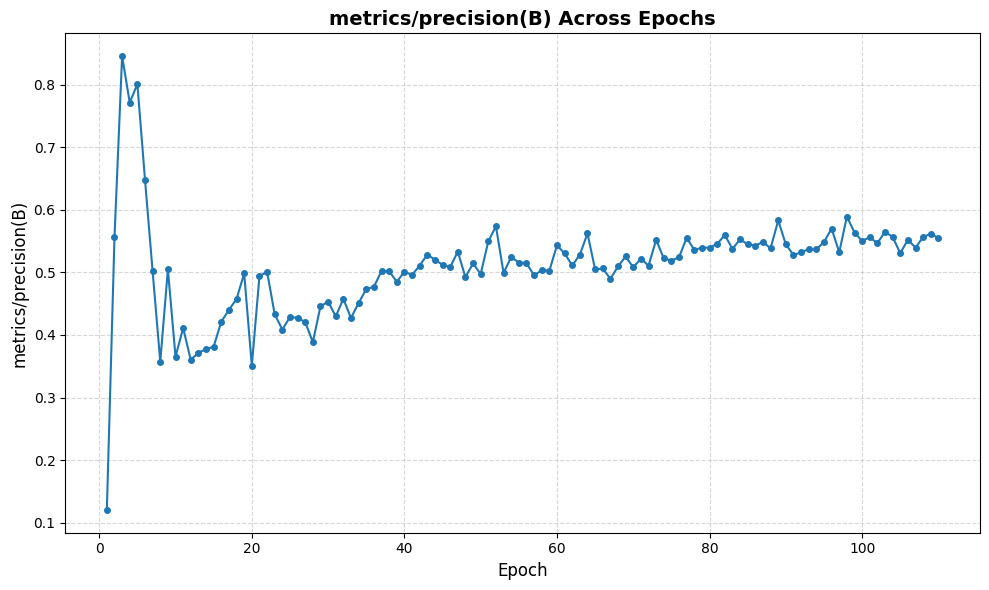

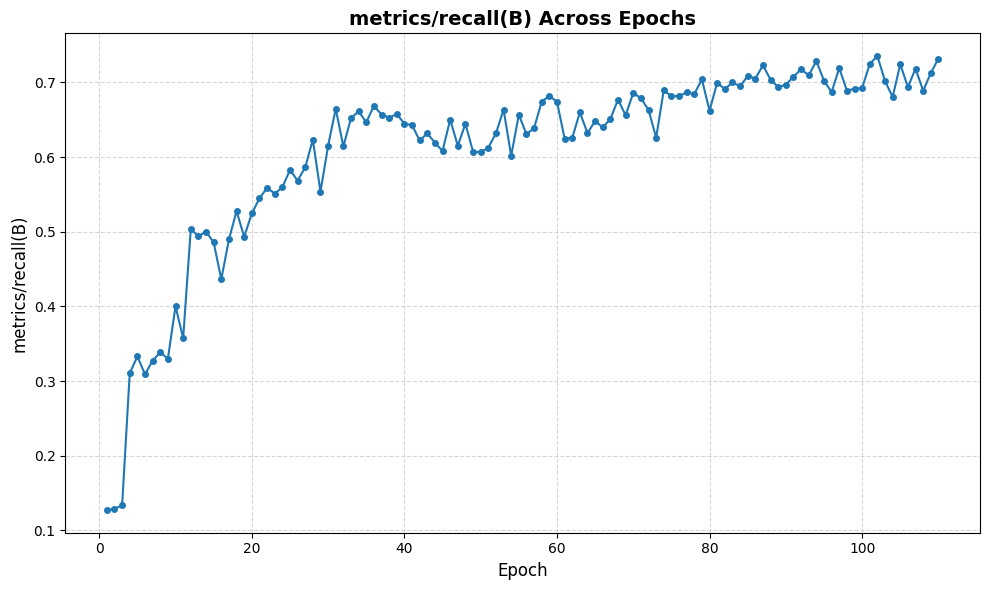

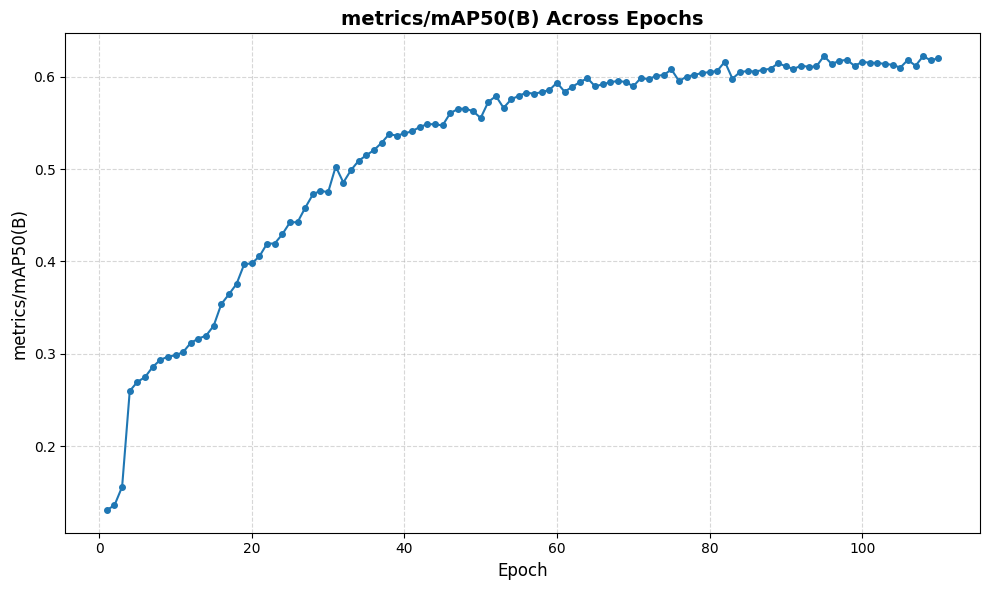

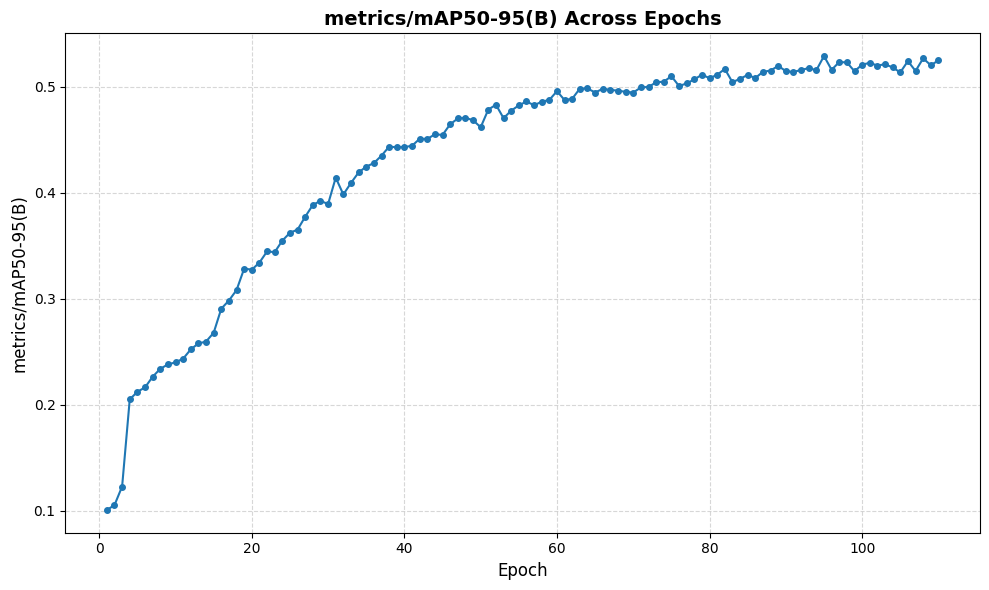

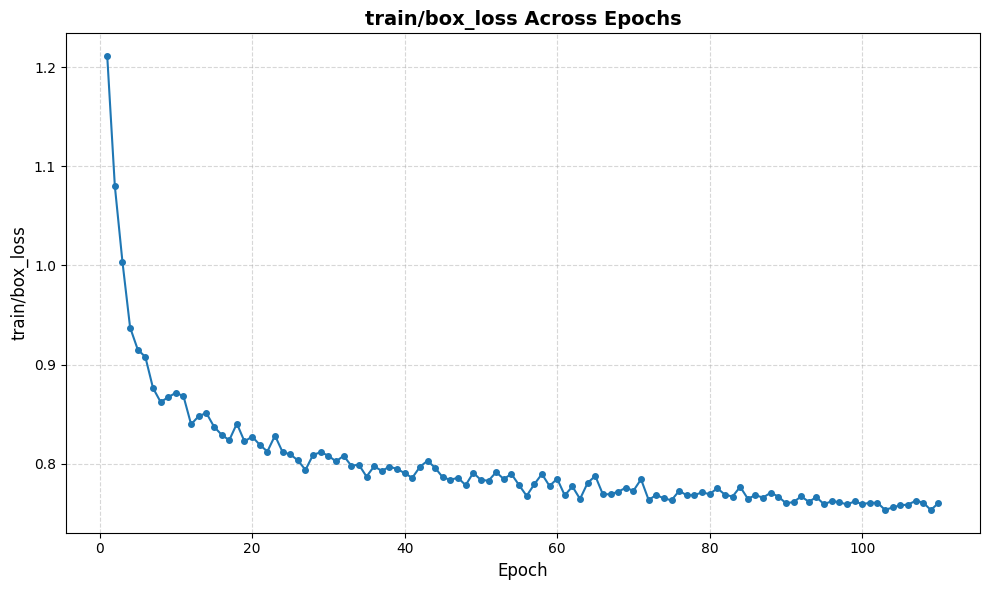

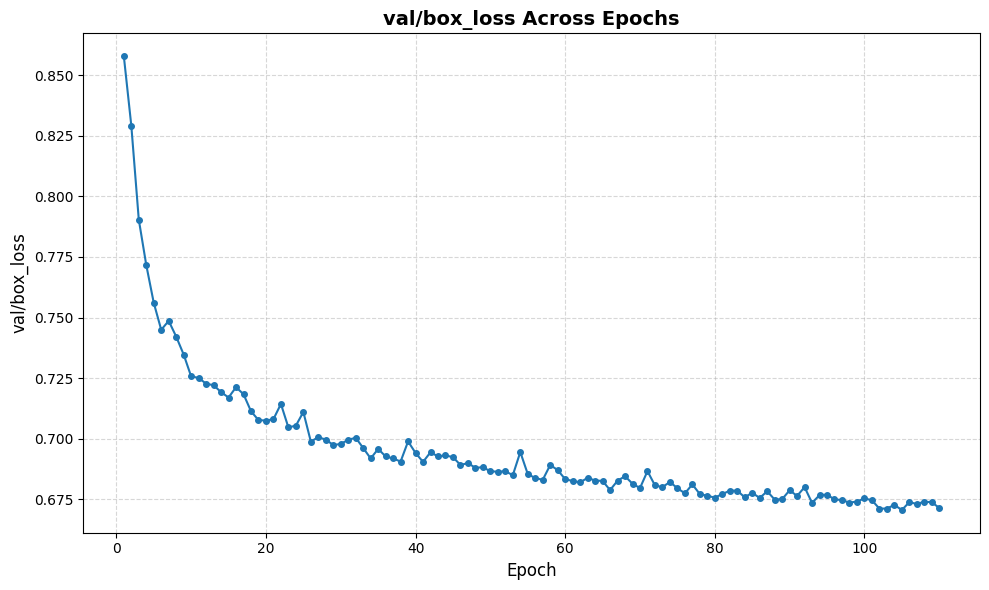

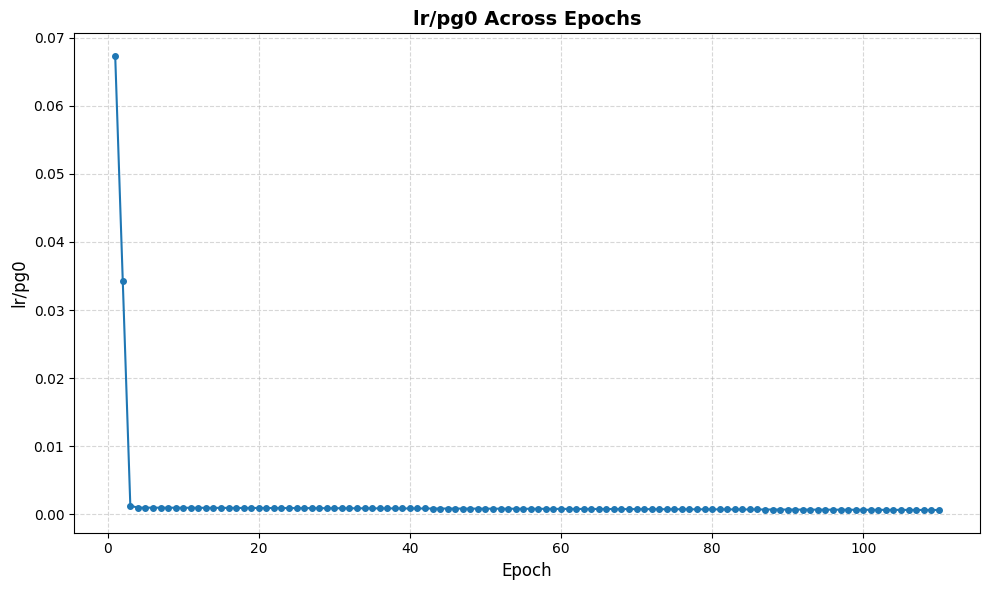


No per-class columns found for metric prefix starting with: metrics/precision(B)/cls

No per-class columns found for metric prefix starting with: metrics/recall(B)/cls

No per-class columns found for metric prefix starting with: metrics/mAP50(B)/cls

No per-class columns found for metric prefix starting with: metrics/mAP50-95(B)/cls

 Visualization complete.


In [8]:
# Visualization for YOLOv8n Training Metrics
import pandas as pd
import matplotlib.pyplot as plt
import os

# Step 1: Path to saved metrics file
# Construct the correct path using save_dir and run_name
save_dir = '/content/drive/MyDrive/malaria_yolov8n_training_results' # Ensure these variables are defined or use the actual paths
run_name = 'malaria_yolo_train'
metrics_log_path = os.path.join(save_dir, run_name, 'results.csv') # Corrected path to results.csv


# Step 2: Load the CSV file
try:
    df = pd.read_csv(metrics_log_path)
    print("✅ Loaded metrics file:")
    display(df.head()) # Use display for better formatting

    # Clean column names (remove leading/trailing spaces)
    df.columns = df.columns.str.strip()

    # Print all column names to inspect for per-class metrics
    print("\nAll columns in the results.csv file:")
    print(df.columns.tolist())


    # Step 3: Choose metrics to visualize
    # Adjust column names based on the actual column names in results.csv
    # Common metrics are ' metrics/precision(B)', ' metrics/recall(B)', ' metrics/mAP50(B)', ' metrics/mAP50-95(B)'
    # Also train/val loss: '        train/box_loss', '  train/cls_loss', '  train/dfl_loss', '          val/box_loss', '    val/cls_loss', '    val/dfl_loss'
    # And lr: '      lr/pg0', '    lr/pg1', '    lr/pg2'

    # Identify available metric columns
    available_metrics = [col for col in df.columns if 'metrics/' in col or 'train/' in col or 'val/' in col or 'lr/' in col]
    print(f"\nAvailable metrics to plot: {available_metrics}")


    # Select a subset of key metrics for plotting
    metrics_to_plot = [
        'metrics/precision(B)',
        'metrics/recall(B)',
        'metrics/mAP50(B)',
        'metrics/mAP50-95(B)',
        'train/box_loss', # Example loss columns
        'val/box_loss',
        'lr/pg0' # Example learning rate
        ]

    # Filter metrics_to_plot to include only those available in the DataFrame
    metrics_to_plot = [metric for metric in metrics_to_plot if metric in df.columns]

    print(f"\nMetrics selected for plotting: {metrics_to_plot}")


    # --- Step 4: Create plots for overall metrics
    if 'epoch' in df.columns:
        epochs = df['epoch']
        for metric in metrics_to_plot:
            plt.figure(figsize=(10, 6))
            plt.plot(epochs, df[metric], marker='o', linestyle='-', markersize=4)
            plt.title(f'{metric} Across Epochs', fontsize=14, weight='bold')
            plt.xlabel('Epoch', fontsize=12)
            plt.ylabel(metric.strip(), fontsize=12) # Strip to clean up label
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.tight_layout()
            plt.show()
    else:
        print(" 'epoch' column not found in results.csv. Cannot plot metrics over epochs.")


    # --- Step 5: Attempt to plot per-class metrics if available
    # Per-class metrics are often logged with specific column names in results.csv
    # Look for columns like 'metrics/precision(B)/cls0', 'metrics/recall(B)/cls0', etc.
    per_class_metrics_prefixes = ['metrics/precision(B)/cls', 'metrics/recall(B)/cls', 'metrics/mAP50(B)/cls', 'metrics/mAP50-95(B)/cls']
    per_class_cols_by_prefix = {prefix: [col for col in df.columns if col.startswith(prefix)] for prefix in per_class_metrics_prefixes}


    class_names = ['red blood cell', 'trophozoite', 'ring', 'schizont', 'gametocyte', 'leukocyte', 'difficult'] # Assuming class names are known


    for prefix, cols in per_class_cols_by_prefix.items():
        if cols and 'epoch' in df.columns:
            # Extract the base metric name (e.g., 'metrics/precision(B)')
            base_metric_name = prefix.replace('/cls', '')
            metric_name_display = base_metric_name.split('/')[-1].replace('(B)', '') # For plot title/label

            plt.figure(figsize=(12, 8))
            for col in cols:
                # Extract class index from column name (e.g., 'cls0' -> 0)
                try:
                    # Get the part after 'cls' and convert to int
                    cls_index_str = col.split('cls')[-1]
                    cls_index = int(cls_index_str)

                    if cls_index < len(class_names):
                        label = class_names[cls_index]
                    else:
                        label = f"Class {cls_index}" # Fallback label
                    plt.plot(epochs, df[col], marker='.', linestyle='-', markersize=4, label=label)
                except Exception as e:
                    print(f"Could not parse class index from column {col}: {e}. Skipping.")
                    continue


            plt.title(f'{metric_name_display} per Class Across Epochs', fontsize=14, weight='bold')
            plt.xlabel('Epoch', fontsize=12)
            plt.ylabel(metric_name_display.strip(), fontsize=12)
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.legend(title='Class', bbox_to_anchor=(1.05, 1), loc='upper left')
            plt.tight_layout()
            plt.show()
        elif not cols:
            print(f"\nNo per-class columns found for metric prefix starting with: {prefix}")
        else:
             print(f"\nCannot plot per-class metrics for prefix {prefix} as 'epoch' column is missing.")


    print("\n Visualization complete.")

except FileNotFoundError:
    print(f"Error: The file {metrics_log_path} was not found. Please ensure training completed successfully.")
except Exception as e:
    print(f"An error occurred while loading or processing the metrics file: {e}")

In [ ]:
# Check GPU utilization and details
# !nvidia-smi